In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("../dataset/Restaurant.csv")
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50163224,BAKED CHEESE HAUS LTD,Manhattan,1,HERALD SQUARE,10001.0,6086301355,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.750542,-73.987541,105.0,4.0,10900.0,1089436.0,1.008100e+09,MN17,POINT (-73.987541021756 40.750541907818)
1,50170678,D'S GRAB N GO,Brooklyn,74,RICHARDSON STREET,11211.0,6463025617,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.718374,-73.949138,301.0,34.0,51500.0,3068058.0,3.027320e+09,BK73,POINT (-73.94913846043 40.718373646442)
2,50171263,NAYA ROCK CENTER LLC,Manhattan,30,ROCKEFELLER PLAZA,10112.0,2124612812,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.758747,-73.978692,105.0,4.0,10400.0,1076262.0,1.012658e+09,MN17,POINT (-73.978692223615 40.758747437799)
3,50172771,AZ&G INC,Queens,133-33,39 AVENUE,11354.0,7188198818,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.759110,-73.834161,407.0,20.0,87100.0,4000000.0,4.049728e+09,QN22,POINT (-73.834160749112 40.759109919719)
4,50165402,AREFIN'S TEA MANIA NEW YORK,Queens,98-04,101 AVENUE,11416.0,3478844480,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.685049,-73.843194,409.0,32.0,4001.0,4439922.0,4.091050e+09,QN53,POINT (-73.843193921 40.685049473493)


In [5]:
df.describe()

,CAMIS,ZIPCODE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,2.967660e+05,293576.000000,280188.000000,295339.000000,295339.000000,292176.000000,292203.000000,292203.000000,2.909300e+05,2.953390e+05
mean,4.806145e+07,10706.923161,25.161749,40.292099,-73.148456,254.923769,20.568711,29882.587995,2.586012e+06,2.478446e+09
std,3.755423e+06,616.227171,18.731612,4.192801,7.611227,130.374503,15.668773,31292.127581,1.356210e+06,1.338448e+09
min,3.007544e+07,6605.000000,0.000000,0.000000,-74.249101,101.000000,1.000000,100.000000,1.000000e+06,1.000000e+00
25%,5.000430e+07,10023.000000,12.000000,40.686661,-73.988620,106.000000,4.000000,8000.000000,1.051461e+06,1.011110e+09
50%,5.009207e+07,11101.000000,21.000000,40.732855,-73.955697,302.000000,20.000000,17300.000000,3.021633e+06,3.008020e+09
75%,5.012999e+07,11232.000000,33.000000,40.761237,-73.893827,402.000000,34.000000,42600.000000,4.011502e+06,4.006290e+09
max,5.018247e+07,69361.000000,203.000000,40.912822,0.000000,595.000000,51.000000,162100.000000,5.799501e+06,5.270001e+09


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296766 entries, 0 to 296765
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296766 non-null  int64  
 1   DBA                    296764 non-null  object 
 2   BORO                   296766 non-null  object 
 3   BUILDING               295807 non-null  object 
 4   STREET                 296765 non-null  object 
 5   ZIPCODE                293576 non-null  float64
 6   PHONE                  296752 non-null  object 
 7   CUISINE DESCRIPTION    293485 non-null  object 
 8   INSPECTION DATE        296766 non-null  object 
 9   ACTION                 293485 non-null  object 
 10  VIOLATION CODE         291191 non-null  object 
 11  VIOLATION DESCRIPTION  291190 non-null  object 
 12  CRITICAL FLAG          296766 non-null  object 
 13  SCORE                  280188 non-null  float64
 14  GRADE                  146385 non-nu

# Early Preprocessing

## Ubah ke Inspection Level ##

In [5]:
for col in ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

record_date = df["RECORD DATE"].dropna().max()
start_date = record_date - pd.DateOffset(years=3)

df_recent = df[
    (df["INSPECTION DATE"].notna()) &
    (df["INSPECTION DATE"] >= start_date) &
    (df["INSPECTION DATE"] <= record_date)
].copy()

df_recent["SCORE"] = pd.to_numeric(df_recent["SCORE"], errors="coerce")
df_recent["BORO"] = df_recent["BORO"].replace("0", "Unknown")
df_recent["VIOLATION CODE"] = df_recent["VIOLATION CODE"].astype("string").str.strip()
df_recent["CRITICAL FLAG"] = df_recent["CRITICAL FLAG"].astype("string").str.strip().str.lower()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

df_ins = (
    df_recent.groupby(inspection_key, as_index=False, dropna=False)
    .agg(
        DBA=("DBA", "first"),
        BORO=("BORO", "first"),
        BUILDING=("BUILDING", "first"),
        STREET=("STREET", "first"),
        ZIPCODE=("ZIPCODE", "first"),
        PHONE=("PHONE", "first"),
        CUISINE_DESCRIPTION=("CUISINE DESCRIPTION", "first"),
        ACTION=("ACTION", "first"),
        SCORE=("SCORE", "first"),
        GRADE=("GRADE", "first"),
        GRADE_DATE=("GRADE DATE", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        Community_Board=("Community Board", "first"),
        Council_District=("Council District", "first"),
        Census_Tract=("Census Tract", "first"),
        BIN=("BIN", "first"),
        BBL=("BBL", "first"),
        NTA=("NTA", "first"),
        violation_count=("VIOLATION CODE", lambda x: x.dropna().ne("").sum()),
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any())
    )
)

df_ins.head()

,CAMIS,INSPECTION DATE,INSPECTION TYPE,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE_DESCRIPTION,ACTION,SCORE,GRADE,GRADE_DATE,Latitude,Longitude,Community_Board,Council_District,Census_Tract,BIN,BBL,NTA,violation_count,critical_count,has_critical
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,38.0,None,NaT,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,2,True
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,12.0,A,2023-08-22,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,10.0,A,2024-11-08,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,7.0,A,2026-02-27,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,2,1,True
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish,Violations were cited in the following area(s).,10.0,A,2023-04-23,40.767326,-73.984310,104.0,3.0,13900.0,1026048.0,1.010480e+09,MN15,2,2,True


In [6]:
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77629 entries, 0 to 77628
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CAMIS                77629 non-null  int64         
 1   INSPECTION DATE      77629 non-null  datetime64[ns]
 2   INSPECTION TYPE      77629 non-null  object        
 3   DBA                  77629 non-null  object        
 4   BORO                 77629 non-null  object        
 5   BUILDING             77390 non-null  object        
 6   STREET               77629 non-null  object        
 7   ZIPCODE              76772 non-null  float64       
 8   PHONE                77626 non-null  object        
 9   CUISINE_DESCRIPTION  77629 non-null  object        
 10  ACTION               77629 non-null  object        
 11  SCORE                68860 non-null  float64       
 12  GRADE                46347 non-null  object        
 13  GRADE_DATE           44221 non-

In [7]:
df_ins.duplicated().sum()

np.int64(0)

In [8]:
df_ins.isna().sum()

CAMIS                      0
INSPECTION DATE            0
INSPECTION TYPE            0
DBA                        0
BORO                       0
BUILDING                 239
STREET                     0
ZIPCODE                  857
PHONE                      3
CUISINE_DESCRIPTION        0
ACTION                     0
SCORE                   8769
GRADE                  31282
GRADE_DATE             33408
Latitude                 386
Longitude                386
Community_Board         1234
Council_District        1230
Census_Tract            1230
BIN                     1604
BBL                      386
NTA                     1234
violation_count            0
critical_count             0
has_critical               0
dtype: int64

**Drop Missing Value in Score**

In [9]:
df_ins = df_ins.dropna(subset=["SCORE"]).copy()
df_ins['SCORE'].isna().sum()

np.int64(0)

**Penjelasan:** Drop baris yang SCORE-nya null karena SCORE adalah kolom target, tidak bisa diimputasi

In [10]:
df_ins.columns

Index(['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'DBA', 'BORO',
       'BUILDING', 'STREET', 'ZIPCODE', 'PHONE', 'CUISINE_DESCRIPTION',
       'ACTION', 'SCORE', 'GRADE', 'GRADE_DATE', 'Latitude', 'Longitude',
       'Community_Board', 'Council_District', 'Census_Tract', 'BIN', 'BBL',
       'NTA', 'violation_count', 'critical_count', 'has_critical'],
      dtype='object')

## Ubah Tipe Data ##

In [11]:
for col in ["INSPECTION DATE", "GRADE_DATE"]:
    df_ins[col] = pd.to_datetime(df_ins[col], errors="coerce")

for col in ["SCORE", "Latitude", "Longitude"]:
    df_ins[col] = pd.to_numeric(df_ins[col], errors="coerce")

df_ins["ZIPCODE"] = df_ins["ZIPCODE"].astype("string").astype("category")

for col in ["BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]:
    df_ins[col] = df_ins[col].astype("category")
    
df_ins.dtypes

CAMIS                           int64
INSPECTION DATE        datetime64[ns]
INSPECTION TYPE              category
DBA                            object
BORO                         category
BUILDING                       object
STREET                         object
ZIPCODE                      category
PHONE                          object
CUISINE_DESCRIPTION          category
ACTION                         object
SCORE                         float64
GRADE                          object
GRADE_DATE             datetime64[ns]
Latitude                      float64
Longitude                     float64
Community_Board               float64
Council_District              float64
Census_Tract                  float64
BIN                           float64
BBL                           float64
NTA                            object
violation_count                 int64
critical_count                  int64
has_critical                     bool
dtype: object

**Penjelasan:** Yang Date itu krn tanggal jd pake datetime, yg score, latitude dan longitude itu bakal diproses secara numerik, selainnya itu krn emang kategorikal jadi diubah ke category aja

## Fitur inti ##

In [12]:
df_ins["inspection_year"] = df_ins["INSPECTION DATE"].dt.year
df_ins["inspection_month"] = df_ins["INSPECTION DATE"].dt.month
df_ins["inspection_quarter"] = df_ins["INSPECTION DATE"].dt.quarter
df_ins["inspection_dayofweek"] = df_ins["INSPECTION DATE"].dt.dayofweek

base_features = [
    "CUISINE_DESCRIPTION",
    "BORO",
    "ZIPCODE",
    "Latitude",
    "Longitude",
    "Community_Board",
    "INSPECTION TYPE",
    "inspection_year",
    "inspection_month",
    "inspection_quarter",
    "inspection_dayofweek"
]

df_base = df_ins[
    ["CAMIS", "INSPECTION DATE", "SCORE"] + base_features
].copy()

df_base.head()

,CAMIS,INSPECTION DATE,SCORE,CUISINE_DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,Community_Board,INSPECTION TYPE,inspection_year,inspection_month,inspection_quarter,inspection_dayofweek
0,30075445,2023-08-01,38.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2023,8,3,1
1,30075445,2023-08-22,12.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Re-inspection,2023,8,3,1
2,30075445,2024-11-08,10.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2024,11,4,4
3,30075445,2026-02-27,7.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2026,2,1,4
4,30191841,2023-04-23,10.0,Irish,Manhattan,10019.0,40.767326,-73.984310,104.0,Cycle Inspection / Initial Inspection,2023,4,2,6


In [13]:
df_base.columns

Index(['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO',
       'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board',
       'INSPECTION TYPE', 'inspection_year', 'inspection_month',
       'inspection_quarter', 'inspection_dayofweek'],
      dtype='object')

In [14]:
df_base.dtypes

CAMIS                            int64
INSPECTION DATE         datetime64[ns]
SCORE                          float64
CUISINE_DESCRIPTION           category
BORO                          category
ZIPCODE                       category
Latitude                       float64
Longitude                      float64
Community_Board                float64
INSPECTION TYPE               category
inspection_year                  int32
inspection_month                 int32
inspection_quarter               int32
inspection_dayofweek             int32
dtype: object

## Handle Missing Value Boro, Zipcode, Cuisine Description, Inspection Type ##

In [15]:
cat_cols = ["BORO", "ZIPCODE", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]

for col in cat_cols:
    df_base[col] = df_base[col].replace(r"^\s*$", pd.NA, regex=True)

    if str(df_base[col].dtype) == "category":
        if "Unknown" not in df_base[col].cat.categories:
            df_base[col] = df_base[col].cat.add_categories(["Unknown"])

    df_base[col] = df_base[col].fillna("Unknown")
    
df_base[cat_cols].isna().sum()

BORO                   0
ZIPCODE                0
CUISINE_DESCRIPTION    0
INSPECTION TYPE        0
dtype: int64

In [16]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68860 entries, 0 to 77627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CAMIS                 68860 non-null  int64         
 1   INSPECTION DATE       68860 non-null  datetime64[ns]
 2   SCORE                 68860 non-null  float64       
 3   CUISINE_DESCRIPTION   68860 non-null  category      
 4   BORO                  68860 non-null  category      
 5   ZIPCODE               68860 non-null  category      
 6   Latitude              68505 non-null  float64       
 7   Longitude             68505 non-null  float64       
 8   Community_Board       67732 non-null  float64       
 9   INSPECTION TYPE       68860 non-null  category      
 10  inspection_year       68860 non-null  int32         
 11  inspection_month      68860 non-null  int32         
 12  inspection_quarter    68860 non-null  int32         
 13  inspection_dayofweek 

## Handle Missing Value Community Board ##

In [17]:
df_base["Community_Board"] = df_base["Community_Board"].astype(str)
df_base["Community_Board"] = df_base["Community_Board"].replace(r"^\s*$", pd.NA, regex=True)
df_base["Community_Board"] = df_base["Community_Board"].fillna("Unknown")
df_base[["Community_Board"]].isna().sum()

Community_Board    0
dtype: int64

## Handle Missing Value Latitude Longitude ##

In [18]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     355
Longitude    355
dtype: int64

In [19]:
df_base["Latitude"] = pd.to_numeric(df_base["Latitude"], errors="coerce")
df_base["Longitude"] = pd.to_numeric(df_base["Longitude"], errors="coerce")

df_base.loc[df_base["Latitude"] == 0, "Latitude"] = pd.NA
df_base.loc[df_base["Longitude"] == 0, "Longitude"] = pd.NA

df_base["Latitude"] = df_base["Latitude"].fillna(
    df_base.groupby("CAMIS")["Latitude"].transform("median")
)

df_base["Longitude"] = df_base["Longitude"].fillna(
    df_base.groupby("CAMIS")["Longitude"].transform("median")
)

df_base["Latitude"] = df_base["Latitude"].fillna(df_base["Latitude"].median())
df_base["Longitude"] = df_base["Longitude"].fillna(df_base["Longitude"].median())

In [20]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     0
Longitude    0
dtype: int64

In [21]:
df_base.isna().sum()

CAMIS                   0
INSPECTION DATE         0
SCORE                   0
CUISINE_DESCRIPTION     0
BORO                    0
ZIPCODE                 0
Latitude                0
Longitude               0
Community_Board         0
INSPECTION TYPE         0
inspection_year         0
inspection_month        0
inspection_quarter      0
inspection_dayofweek    0
dtype: int64

## Top Category Cuisine & Inspection Type ##

In [22]:
TOP_N_CUISINE = 15
TOP_N_INSTYPE = 5

top_cuisine = df_base["CUISINE_DESCRIPTION"].value_counts().nlargest(TOP_N_CUISINE).index
df_base["CUISINE_DESCRIPTION"] = (
    df_base["CUISINE_DESCRIPTION"]
    .apply(lambda x: x if x in top_cuisine else "Other")
)

top_instype = df_base["INSPECTION TYPE"].value_counts().nlargest(TOP_N_INSTYPE).index
df_base["INSPECTION TYPE"] = (
    df_base["INSPECTION TYPE"]
    .apply(lambda x: x if x in top_instype else "Other")
)

In [23]:
print(df_base["CUISINE_DESCRIPTION"].value_counts())
print()
print(df_base["INSPECTION TYPE"].value_counts())
print(df_base["CUISINE_DESCRIPTION"].nunique())
print(df_base["INSPECTION TYPE"].nunique())

CUISINE_DESCRIPTION
Other                             18539
American                          11072
Chinese                            6221
Coffee/Tea                         5862
Pizza                              4184
Latin American                     2900
Bakery Products/Desserts           2778
Mexican                            2708
Japanese                           2364
Caribbean                          2259
Italian                            2191
Chicken                            1914
Donuts                             1701
Juice, Smoothies, Fruit Salads     1418
Spanish                            1414
Hamburgers                         1335
Name: count, dtype: int64

INSPECTION TYPE
Cycle Inspection / Initial Inspection            38133
Cycle Inspection / Re-inspection                 14453
Pre-permit (Operational) / Initial Inspection     9378
Other                                             3067
Pre-permit (Operational) / Re-inspection          2774
Cycle Inspection / Reo

**Penjelasan:** Cuisine diambil yang top 15 agar tidak terlalu banyak kategori karena diluar top 15 jumlahnya juga dikit, inspection type diambil yang top 5 aja dengan alasan yang sama selebihnya dikelompokkan sebagai Other

# Advanced Preprocessing

## Step 1 - Advanced Preprocessing: Feature Engineering dari Violation ##

- `df_ins` sudah mengagregasi `violation_count`, `critical_count`, dan `has_critical`
- Namun fitur-fitur ini **tidak ikut masuk ke `df_base`** saat pemilihan kolom
- Langkah ini melengkapi fitur violation yang kurang, lalu menarik semuanya ke `df_base`


In [24]:
inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

viol_clean = df_recent.copy()
viol_clean["VIOLATION CODE"]  = viol_clean["VIOLATION CODE"].astype(str).str.strip()
viol_clean["CRITICAL FLAG"]   = viol_clean["CRITICAL FLAG"].astype(str).str.strip().str.lower()

viol_clean = viol_clean[
    viol_clean["VIOLATION CODE"].notna() &
    (viol_clean["VIOLATION CODE"] != "") &
    (viol_clean["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_dedup = viol_clean.drop_duplicates(
    subset=inspection_key + ["VIOLATION CODE"]
).copy()

viol_features = (
    viol_dedup.groupby(inspection_key, as_index=False)
    .agg(
        violation_count    = ("VIOLATION CODE", "count"),
        unique_viol_codes  = ("VIOLATION CODE", "nunique"),
        critical_count     = ("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        noncritical_count  = ("CRITICAL FLAG", lambda x: (x != "critical").sum()),
        has_critical       = ("CRITICAL FLAG", lambda x: (x == "critical").any()),
    )
)

viol_features["critical_ratio"] = (
    viol_features["critical_count"] / viol_features["violation_count"].replace(0, pd.NA)
).fillna(0)

print("Shape viol_features:", viol_features.shape)
viol_features.head()

Shape viol_features: (77629, 9)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,violation_count,unique_viol_codes,critical_count,noncritical_count,has_critical,critical_ratio
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,3,3,2,1,True,0.666667
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,3,3,1,2,True,0.333333
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,3,3,1,2,True,0.333333
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,2,2,1,1,True,0.500000
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,2,2,2,0,True,1.000000


**1b. Binary Flag untuk Top Violation Codes dengan score tertinggi**

Dari EDA diketahui 9/10 violation code dengan median score tertinggi adalah critical code (05F, 06C, dst).
Membuat flag kehadiran kode-kode tersebut sebagai fitur eksplisit.


In [ ]:
TOP_VIOL_CODES = ["05F", "06C", "06D", "06E", "04L", "08A", "04N", "02G", "10F", "09C"]

code_pivot = (
    viol_dedup[viol_dedup["VIOLATION CODE"].isin(TOP_VIOL_CODES)]
    .assign(val=1)
    .pivot_table(
        index=inspection_key,
        columns="VIOLATION CODE",
        values="val",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

code_pivot.columns.name = None
code_pivot = code_pivot.rename(
    columns={c: f"viol_{c}" for c in TOP_VIOL_CODES if c in code_pivot.columns}
)

print("Shape code_pivot:", code_pivot.shape)
code_pivot.head()

Shape code_pivot: (60600, 13)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,viol_02G,viol_04L,viol_04N,viol_05F,viol_06C,viol_06D,viol_06E,viol_08A,viol_09C,viol_10F
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,0,1,0,0,0,0,0,1,0,0
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,0,1,0,0,0,0,0,1,0,0
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,0,0,0,0,1,0,0,0,0,1
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,0,1
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,0,0,0,0,1,0,1,0,0,0


In [26]:
for col in inspection_key:
    viol_features[col]  = viol_features[col].astype(str)
    code_pivot[col]     = code_pivot[col].astype(str)
    df_base[col]        = df_base[col].astype(str)

df_base = df_base.merge(viol_features, on=inspection_key, how="left")

df_base = df_base.merge(code_pivot, on=inspection_key, how="left")

viol_numeric_cols = (
    ["violation_count", "unique_viol_codes", "critical_count",
     "noncritical_count", "critical_ratio"]
    + [c for c in df_base.columns if c.startswith("viol_")]
)
df_base[viol_numeric_cols] = df_base[viol_numeric_cols].fillna(0)
df_base["has_critical"] = df_base["has_critical"].fillna(False)

print("Shape df_base setelah merge violation features:", df_base.shape)
print("\nKolom baru yang ditambahkan:")
print([c for c in df_base.columns if c in viol_numeric_cols or c == "has_critical"])

Shape df_base setelah merge violation features: (68860, 30)

Kolom baru yang ditambahkan:
['violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02G', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'viol_10F']


C:\Users\MSI SWORD 16\AppData\Local\Temp\ipykernel_32460\2164251100.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_base["has_critical"] = df_base["has_critical"].fillna(False)


In [27]:
print("=== Info df_base ===")
print(df_base[viol_numeric_cols + ["has_critical"]].describe())
print()
print("=== Missing values fitur violation ===")
print(df_base[viol_numeric_cols + ["has_critical"]].isna().sum())
print()
print("=== Contoh data ===")
df_base[[
    "CAMIS", "INSPECTION DATE", "SCORE",
    "violation_count", "critical_count", "noncritical_count",
    "unique_viol_codes", "critical_ratio", "has_critical"
]].head(10)

=== Info df_base ===
       violation_count  unique_viol_codes  critical_count  noncritical_count  \
count     68860.000000       68860.000000    68860.000000       68860.000000   
mean          3.246660           3.246660        1.815800           1.430860   
std           2.112278           2.112278        1.526577           1.067399   
min           0.000000           0.000000        0.000000           0.000000   
25%           2.000000           2.000000        1.000000           1.000000   
50%           3.000000           3.000000        1.000000           1.000000   
75%           4.000000           4.000000        3.000000           2.000000   
max          19.000000          19.000000       13.000000           8.000000   

       critical_ratio      viol_02G      viol_04L      viol_04N      viol_05F  \
count    68860.000000  68860.000000  68860.000000  68860.000000  68860.000000   
mean         0.510207      0.220447      0.169300      0.131528      0.008205   
std          0.

,CAMIS,INSPECTION DATE,SCORE,violation_count,critical_count,noncritical_count,unique_viol_codes,critical_ratio,has_critical
0,30075445,2023-08-01,38.0,3.0,2.0,1.0,3.0,0.666667,True
1,30075445,2023-08-22,12.0,3.0,1.0,2.0,3.0,0.333333,True
2,30075445,2024-11-08,10.0,3.0,1.0,2.0,3.0,0.333333,True
3,30075445,2026-02-27,7.0,2.0,1.0,1.0,2.0,0.500000,True
4,30191841,2023-04-23,10.0,2.0,2.0,0.0,2.0,1.000000,True
5,30191841,2024-11-20,24.0,6.0,2.0,4.0,6.0,0.333333,True
6,30191841,2025-02-20,10.0,2.0,2.0,0.0,2.0,1.000000,True
7,40356018,2024-04-16,0.0,1.0,0.0,1.0,1.0,0.000000,False
8,40356018,2025-09-17,10.0,2.0,1.0,1.0,2.0,0.500000,True
9,40356483,2023-11-16,35.0,6.0,3.0,3.0,6.0,0.500000,True


## Step 2 - Advanced Preprocessing: Feature Engineering Historis per Restoran ##

**Konteks & Anti Data Leakage:**

Karena 68%+ restoran adalah **repeat offender**, riwayat inspeksi sebelumnya sangat prediktif terhadap score saat ini.

Aturan krusial: **fitur historis hanya boleh menggunakan data dari inspeksi SEBELUM tanggal inspeksi yang sedang diprediksi.**
Jika memakai data dari tanggal yang sama atau sesudahnya → **data leakage** → model terlihat bagus saat training tapi gagal di production.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `prev_score` | Score inspeksi terakhir restoran sebelum inspeksi ini |
| `avg_score_last3` | Rata-rata score 3 inspeksi terakhir |
| `n_prev_inspections` | Jumlah inspeksi sebelumnya |
| `days_since_last_inspection` | Jarak hari dari inspeksi terakhir |
| `prev_critical_count` | Jumlah critical violation di inspeksi terakhir |
| `ever_had_critical` | Apakah restoran pernah dapat critical violation sebelumnya |


In [28]:
df_hist = df_base.copy()
df_hist["INSPECTION DATE"] = pd.to_datetime(df_hist["INSPECTION DATE"])
df_hist = df_hist.sort_values(["CAMIS", "INSPECTION DATE"]).reset_index(drop=True)

df_hist["prev_score"] = (
    df_hist.groupby("CAMIS")["SCORE"]
    .shift(1) 
)

df_hist["avg_score_last3"] = (
    df_hist.groupby("CAMIS")["SCORE"]
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

df_hist["n_prev_inspections"] = (
    df_hist.groupby("CAMIS").cumcount()
)

df_hist["prev_inspection_date"] = (
    df_hist.groupby("CAMIS")["INSPECTION DATE"].shift(1)
)
df_hist["days_since_last_inspection"] = (
    (df_hist["INSPECTION DATE"] - df_hist["prev_inspection_date"]).dt.days
)
df_hist = df_hist.drop(columns=["prev_inspection_date"])

df_hist["prev_critical_count"] = (
    df_hist.groupby("CAMIS")["critical_count"].shift(1)
)

df_hist["ever_had_critical"] = (
    df_hist.groupby("CAMIS")["has_critical"]
    .transform(lambda x: x.shift(1).fillna(False).cumsum()) > 0
)

print("Shape df_hist:", df_hist.shape)
print()
print("Missing values fitur historis:")
hist_cols = ["prev_score", "avg_score_last3", "n_prev_inspections",
             "days_since_last_inspection", "prev_critical_count", "ever_had_critical"]
print(df_hist[hist_cols].isna().sum())

C:\Users\MSI SWORD 16\AppData\Local\Temp\ipykernel_32460\489079083.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.shift(1).fillna(False).cumsum()) > 0


Shape df_hist: (68860, 36)

Missing values fitur historis:
prev_score                    27071
avg_score_last3               27071
n_prev_inspections                0
days_since_last_inspection    27071
prev_critical_count           27071
ever_had_critical                 0
dtype: int64


**Handle Missing Value Fitur Historis**

Inspeksi pertama setiap restoran (`n_prev_inspections == 0`) akan selalu NaN pada `prev_score`, `avg_score_last3`, dll.
karena belum ada riwayat — ini **bukan error**, melainkan kondisi wajar.

Strategi imputasi:
- `prev_score` & `avg_score_last3` → isi dengan **median global** sebagai baseline
- `days_since_last_inspection` → isi dengan nilai **besar (999)** sebagai sinyal "pertama kali"
- `prev_critical_count` → isi **0** (belum pernah ada critical)
- `ever_had_critical` → isi **False**


In [30]:
global_median_score = df_hist["SCORE"].median()

df_hist["prev_score"]                = df_hist["prev_score"].fillna(global_median_score)
df_hist["avg_score_last3"]           = df_hist["avg_score_last3"].fillna(global_median_score)
df_hist["days_since_last_inspection"]= df_hist["days_since_last_inspection"].fillna(999)
df_hist["prev_critical_count"]       = df_hist["prev_critical_count"].fillna(0)
df_hist["ever_had_critical"]         = df_hist["ever_had_critical"].fillna(False)

print("Missing values setelah imputasi:")
print(df_hist[hist_cols].isna().sum())
print()

df_base = df_hist.copy()

print("=== Distribusi fitur historis ===")
df_base[hist_cols].describe()

Missing values setelah imputasi:
prev_score                    0
avg_score_last3               0
n_prev_inspections            0
days_since_last_inspection    0
prev_critical_count           0
ever_had_critical             0
dtype: int64

=== Distribusi fitur historis ===


,prev_score,avg_score_last3,n_prev_inspections,days_since_last_inspection,prev_critical_count
count,68860.000000,68860.000000,68860.000000,68860.000000,68860.000000
mean,17.892114,18.125850,1.095353,573.208205,1.268995
std,13.554778,11.948668,1.239170,378.471862,1.648423
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,13.000000,13.000000,0.000000,210.000000,0.000000
50%,13.000000,13.000000,1.000000,512.000000,1.000000
75%,21.000000,21.500000,2.000000,999.000000,2.000000
max,180.000000,180.000000,13.000000,1078.000000,13.000000


## Step 3 - Advanced Preprocessing: Feature Engineering Geospasial (Target Encoding) ##

**Konteks:**

Dari EDA diketahui lokasi (BORO, ZIPCODE, Community Board) berpengaruh terhadap SCORE.
Daripada hanya pakai label encoding biasa, kami membuat **Target Encoding berbasis agregasi** —
mengganti nilai kategorikal dengan statistik SCORE historis di wilayah tersebut.

**Strategi Anti Data Leakage:**
Target encoding harus dihitung dari **data training saja** dan di-apply ke test set.
Di tahap ini (sebelum split), kami gunakan pendekatan **Leave-One-Out** atau cukup
hitung dari keseluruhan data sebagai proxy — split resmi akan dilakukan di Step 8.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `boro_median_score` | Median score historis per BORO |
| `boro_mean_score` | Mean score historis per BORO |
| `zipcode_median_score` | Median score historis per ZIPCODE |
| `zipcode_mean_score` | Mean score historis per ZIPCODE |
| `community_board_median_score` | Median score historis per Community Board |


In [31]:
boro_stats = (
    df_base.groupby("BORO")["SCORE"]
    .agg(boro_median_score="median", boro_mean_score="mean")
    .reset_index()
)

zipcode_stats = (
    df_base.groupby("ZIPCODE")["SCORE"]
    .agg(zipcode_median_score="median", zipcode_mean_score="mean")
    .reset_index()
)

cb_stats = (
    df_base.groupby("Community_Board")["SCORE"]
    .agg(community_board_median_score="median")
    .reset_index()
)

df_base = df_base.merge(boro_stats,    on="BORO",            how="left")
df_base = df_base.merge(zipcode_stats, on="ZIPCODE",         how="left")
df_base = df_base.merge(cb_stats,      on="Community_Board", how="left")

global_median = df_base["SCORE"].median()
geo_encode_cols = [
    "boro_median_score", "boro_mean_score",
    "zipcode_median_score", "zipcode_mean_score",
    "community_board_median_score"
]
df_base[geo_encode_cols] = df_base[geo_encode_cols].fillna(global_median)

print("Shape df_base setelah geospatial encoding:", df_base.shape)
print()
print("Missing values fitur geospatial:")
print(df_base[geo_encode_cols].isna().sum())

Shape df_base setelah geospatial encoding: (68860, 41)

Missing values fitur geospatial:
boro_median_score               0
boro_mean_score                 0
zipcode_median_score            0
zipcode_mean_score              0
community_board_median_score    0
dtype: int64


C:\Users\MSI SWORD 16\AppData\Local\Temp\ipykernel_32460\2722056928.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_base.groupby("BORO")["SCORE"]
C:\Users\MSI SWORD 16\AppData\Local\Temp\ipykernel_32460\2722056928.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_base.groupby("ZIPCODE")["SCORE"]


In [32]:
geo_hist_cols = geo_encode_cols + hist_cols

print("=== Distribusi fitur geospatial ===")
print(df_base[geo_encode_cols].describe())
print()
print("=== Contoh Perbandingan: BORO vs boro_median_score ===")
print(df_base.groupby("BORO")[["boro_median_score", "boro_mean_score"]].first().sort_values("boro_median_score", ascending=False))
print()
print("=== Total kolom df_base saat ini ===")
print(f"Shape: {df_base.shape}")
print(df_base.columns.tolist())


=== Distribusi fitur geospatial ===
       boro_median_score  boro_mean_score  zipcode_median_score  \
count       68860.000000     68860.000000          68860.000000   
mean           12.625385        18.118501             12.754676   
std             0.484027         0.858589              1.547715   
min            12.000000        15.463415              2.000000   
25%            12.000000        17.384430             12.000000   
50%            13.000000        17.723636             13.000000   
75%            13.000000        18.158726             13.000000   
max            13.000000        19.551193             28.000000   

       zipcode_mean_score  community_board_median_score  
count        68860.000000                  68860.000000  
mean            18.118501                     12.773003  
std              2.068082                      1.044980  
min              4.000000                      4.000000  
25%             16.851372                     12.000000  
50%         

C:\Users\MSI SWORD 16\AppData\Local\Temp\ipykernel_32460\445216009.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_base.groupby("BORO")[["boro_median_score", "boro_mean_score"]].first().sort_values("boro_median_score", ascending=False))


## Correlation Analysis: Seleksi Fitur terhadap Target (SCORE) ##

**Tujuan:** Identifikasi fitur mana yang benar-benar berkorelasi dengan SCORE sebelum masuk modeling.

Dua pendekatan digunakan secara bersamaan:
- **Pearson / Spearman** → untuk fitur numerik (linear vs monotonic)
- **Eta-squared (η²)** → untuk fitur kategorikal (kekuatan asosiasi via ANOVA)

Threshold keputusan (bisa disesuaikan):
- Numerik: |Spearman ρ| ≥ 0.05 → **keep**
- Kategorikal: η² ≥ 0.01 → **keep** (efek kecil tapi informatif)


In [33]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

exclude_cols = {"CAMIS", "INSPECTION DATE", "SCORE"}
num_cols = [
    c for c in df_base.select_dtypes(include="number").columns
    if c not in exclude_cols
]

corr_results = []
for col in num_cols:
    valid = df_base[[col, "SCORE"]].dropna()
    if len(valid) < 30:
        continue
    pearson_r,  pearson_p  = stats.pearsonr(valid[col],  valid["SCORE"])
    spearman_r, spearman_p = stats.spearmanr(valid[col], valid["SCORE"])
    corr_results.append({
        "feature":     col,
        "pearson_r":   round(pearson_r,  4),
        "pearson_p":   round(pearson_p,  4),
        "spearman_r":  round(spearman_r, 4),
        "spearman_p":  round(spearman_p, 4),
        "abs_spearman": abs(spearman_r),
    })

df_corr = (
    pd.DataFrame(corr_results)
    .sort_values("abs_spearman", ascending=False)
    .reset_index(drop=True)
)

SPEARMAN_THRESHOLD = 0.05
df_corr["keep"] = df_corr["abs_spearman"] >= SPEARMAN_THRESHOLD

print(f"Total fitur numerik diperiksa: {len(df_corr)}")
print(f"Fitur yang cukup berkorelasi (|ρ| ≥ {SPEARMAN_THRESHOLD}): {df_corr['keep'].sum()}")
print(f"Fitur yang lemah / tidak berkorelasi: {(~df_corr['keep']).sum()}")
print()
df_corr


Total fitur numerik diperiksa: 31
Fitur yang cukup berkorelasi (|ρ| ≥ 0.05): 22
Fitur yang lemah / tidak berkorelasi: 9



,feature,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman,keep
0,critical_count,0.8106,0.0000,0.8381,0.0000,0.838134,True
1,unique_viol_codes,0.7831,0.0000,0.8176,0.0000,0.817552,True
2,violation_count,0.7831,0.0000,0.8176,0.0000,0.817552,True
3,viol_08A,0.4211,0.0000,0.4795,0.0000,0.479486,True
4,critical_ratio,0.2954,0.0000,0.4245,0.0000,0.424459,True
5,viol_02G,0.3507,0.0000,0.3808,0.0000,0.380793,True
6,noncritical_count,0.3904,0.0000,0.3651,0.0000,0.365133,True
7,viol_04L,0.2862,0.0000,0.3289,0.0000,0.328939,True
8,viol_04N,0.2572,0.0000,0.2806,0.0000,0.280551,True
9,viol_06C,0.2749,0.0000,0.2740,0.0000,0.273971,True


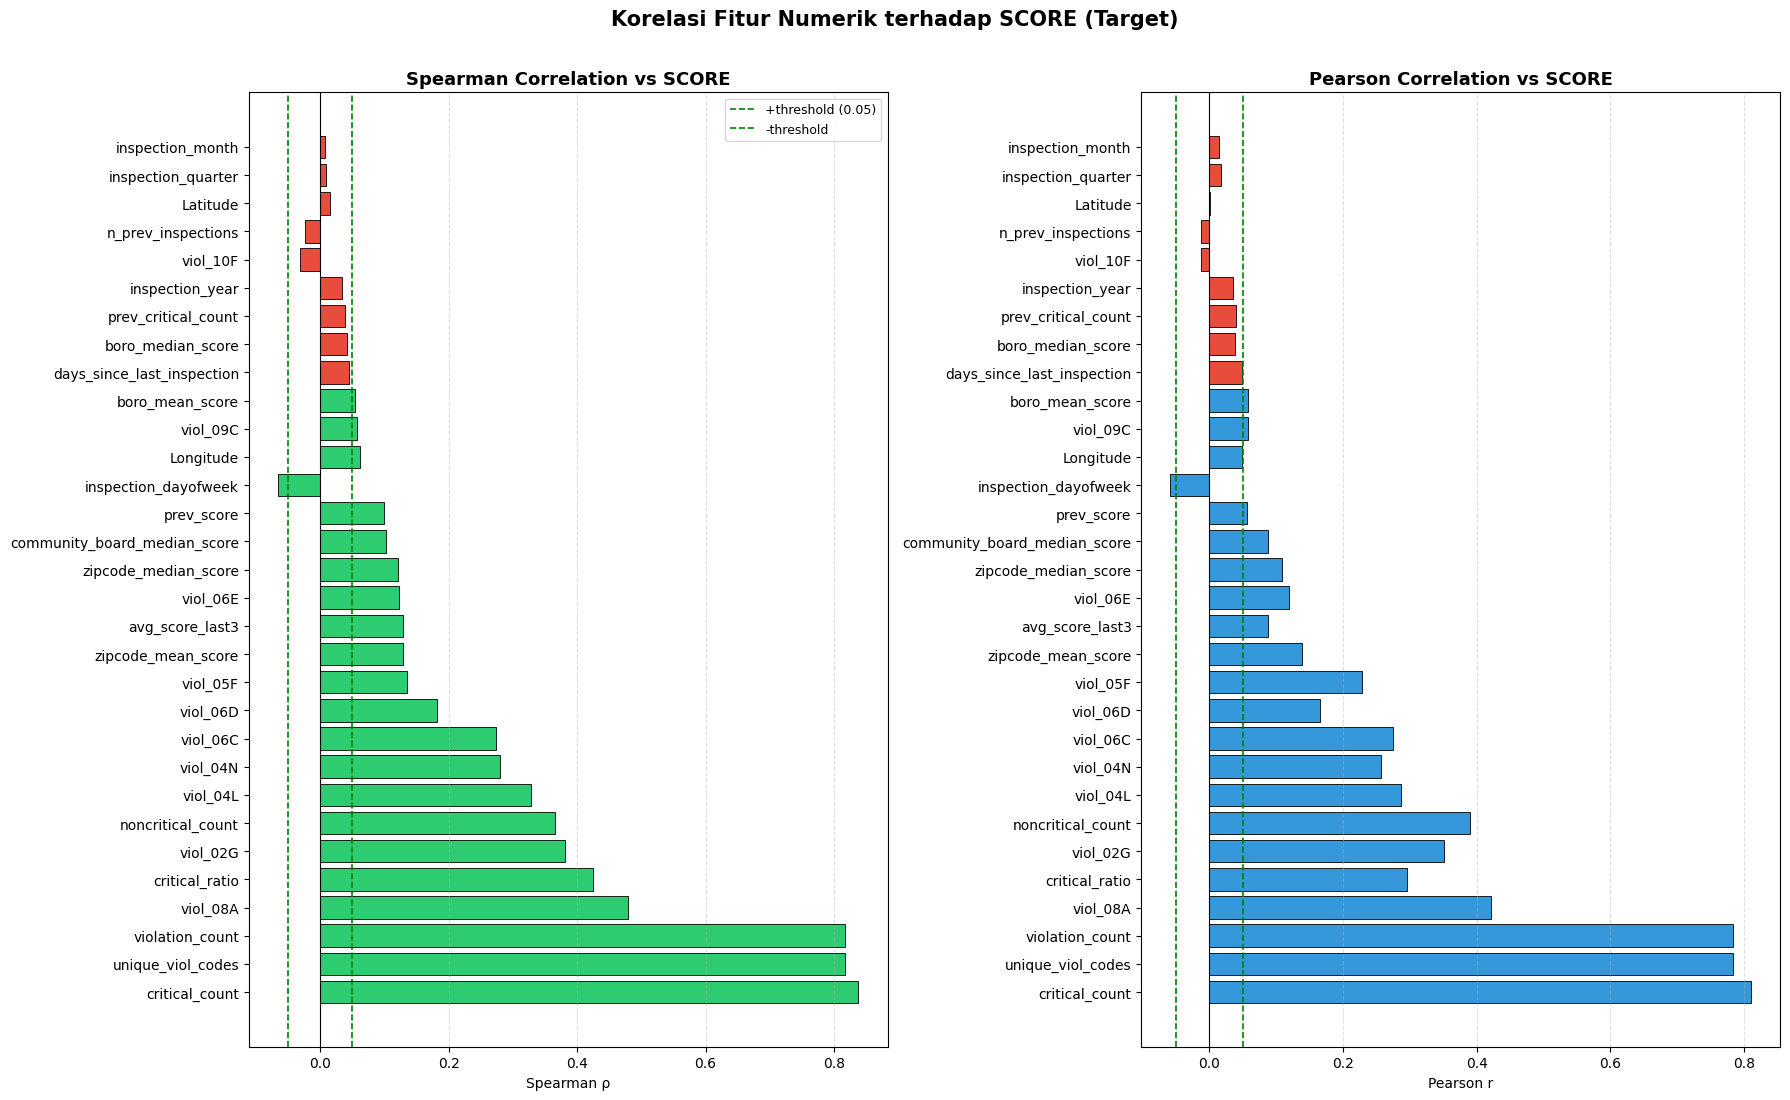


Fitur LEMAH (akan dipertimbangkan untuk di-drop):
['days_since_last_inspection', 'boro_median_score', 'prev_critical_count', 'inspection_year', 'viol_10F', 'n_prev_inspections', 'Latitude', 'inspection_quarter', 'inspection_month']

Fitur KUAT (dipertahankan):
['critical_count', 'unique_viol_codes', 'violation_count', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_04N', 'viol_06C', 'viol_06D', 'viol_05F', 'zipcode_mean_score', 'avg_score_last3', 'viol_06E', 'zipcode_median_score', 'community_board_median_score', 'prev_score', 'inspection_dayofweek', 'Longitude', 'viol_09C', 'boro_mean_score']


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(df_corr) * 0.35)))

colors_sp = ["#2ecc71" if k else "#e74c3c" for k in df_corr["keep"]]
axes[0].barh(df_corr["feature"], df_corr["spearman_r"], color=colors_sp, edgecolor="black", linewidth=0.6)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"+threshold ({SPEARMAN_THRESHOLD})")
axes[0].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"-threshold")
axes[0].set_title("Spearman Correlation vs SCORE", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Spearman ρ")
axes[0].legend(fontsize=9)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

colors_pe = ["#3498db" if k else "#e74c3c" for k in df_corr["keep"]]
axes[1].barh(df_corr["feature"], df_corr["pearson_r"], color=colors_pe, edgecolor="black", linewidth=0.6)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)
axes[1].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)
axes[1].set_title("Pearson Correlation vs SCORE", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Pearson r")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Korelasi Fitur Numerik terhadap SCORE (Target)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nFitur LEMAH (akan dipertimbangkan untuk di-drop):")
print(df_corr[~df_corr["keep"]]["feature"].tolist())
print("\nFitur KUAT (dipertahankan):")
print(df_corr[df_corr["keep"]]["feature"].tolist())


In [ ]:
cat_cols_to_check = [
    "BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE", "ZIPCODE", "Community_Board"
]

eta_results = []
for col in cat_cols_to_check:
    tmp = df_base[[col, "SCORE"]].dropna().copy()
    tmp[col] = tmp[col].astype(str)

    groups = [grp["SCORE"].values for _, grp in tmp.groupby(col) if len(grp) >= 5]
    if len(groups) < 2:
        continue

    f_stat, p_val = stats.f_oneway(*groups)

    grand_mean = tmp["SCORE"].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((tmp["SCORE"] - grand_mean)**2)
    eta_sq     = ss_between / ss_total if ss_total > 0 else 0

    eta_results.append({
        "feature":    col,
        "f_stat":     round(f_stat, 4),
        "p_value":    round(p_val, 6),
        "eta_squared": round(eta_sq, 6),
        "n_categories": tmp[col].nunique(),
    })

df_eta = (
    pd.DataFrame(eta_results)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

ETA_THRESHOLD = 0.01
df_eta["keep"] = df_eta["eta_squared"] >= ETA_THRESHOLD
df_eta["effect_size"] = df_eta["eta_squared"].apply(
    lambda x: "Large (η²≥0.14)" if x >= 0.14
    else "Medium (η²≥0.06)" if x >= 0.06
    else "Small (η²≥0.01)" if x >= 0.01
    else "Negligible"
)

print(f"Total fitur kategorikal diperiksa: {len(df_eta)}")
print()
df_eta


Total fitur kategorikal diperiksa: 5



,feature,f_stat,p_value,eta_squared,n_categories,keep,effect_size
0,CUISINE_DESCRIPTION,112.4816,0.0,0.023922,16,True,Small (η²≥0.01)
1,INSPECTION TYPE,288.1229,0.0,0.020494,6,True,Small (η²≥0.01)
2,ZIPCODE,6.5192,0.0,0.018733,230,True,Small (η²≥0.01)
3,Community_Board,11.8809,0.0,0.011102,70,True,Small (η²≥0.01)
4,BORO,45.3612,0.0,0.003283,6,False,Negligible


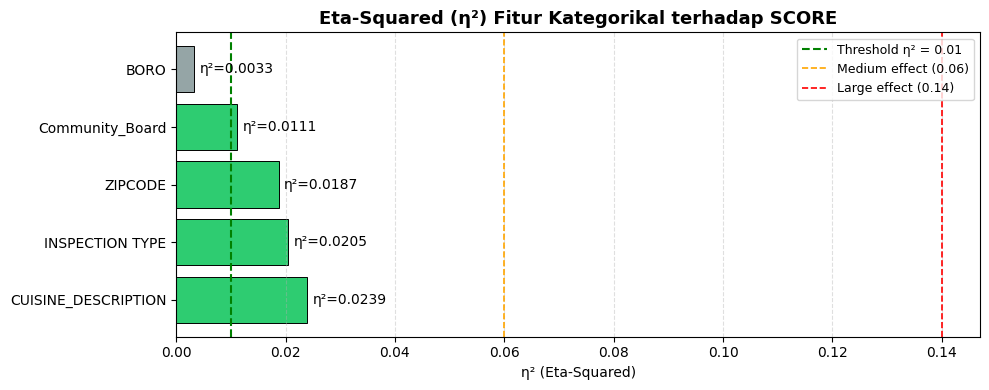

In [36]:
fig, ax = plt.subplots(figsize=(10, max(4, len(df_eta) * 0.7)))

color_map = {
    "Large (η²≥0.14)":   "#c0392b",
    "Medium (η²≥0.06)":  "#e67e22",
    "Small (η²≥0.01)":   "#2ecc71",
    "Negligible":         "#95a5a6",
}
bar_colors = [color_map[e] for e in df_eta["effect_size"]]

bars = ax.barh(df_eta["feature"], df_eta["eta_squared"],
               color=bar_colors, edgecolor="black", linewidth=0.7)
ax.axvline(ETA_THRESHOLD, color="green", linestyle="--", linewidth=1.5,
           label=f"Threshold η² = {ETA_THRESHOLD}")
ax.axvline(0.06, color="orange", linestyle="--", linewidth=1.2, label="Medium effect (0.06)")
ax.axvline(0.14, color="red",    linestyle="--", linewidth=1.2, label="Large effect (0.14)")

for bar, val in zip(bars, df_eta["eta_squared"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"η²={val:.4f}", va="center", fontsize=10)

ax.set_title("Eta-Squared (η²) Fitur Kategorikal terhadap SCORE", fontsize=13, fontweight="bold")
ax.set_xlabel("η² (Eta-Squared)")
ax.legend(fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [47]:
print("=" * 65)
print("  REKOMENDASI FITUR BERDASARKAN KORELASI")
print("=" * 65)

keep_num  = df_corr[df_corr["keep"]]["feature"].tolist()
drop_num  = df_corr[~df_corr["keep"]]["feature"].tolist()
keep_cat  = df_eta[df_eta["keep"]]["feature"].tolist()
drop_cat  = df_eta[~df_eta["keep"]]["feature"].tolist()

print(f"\nFitur NUMERIK dipertahankan ({len(keep_num)}):")
for f in keep_num:
    row = df_corr[df_corr["feature"] == f].iloc[0]
    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur NUMERIK lemah — pertimbangkan DROP ({len(drop_num)}):")
for f in drop_num:
    row = df_corr[df_corr["feature"] == f].iloc[0]
    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur KATEGORIKAL dipertahankan ({len(keep_cat)}):")
for f in keep_cat:
    row = df_eta[df_eta["feature"] == f].iloc[0]
    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

print(f"\nFitur KATEGORIKAL lemah — pertimbangkan DROP ({len(drop_cat)}):")
for f in drop_cat:
    row = df_eta[df_eta["feature"] == f].iloc[0]
    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

recommended_num = keep_num
recommended_cat = keep_cat
print(f"\n{'='*65}")
print(f"  TOTAL FITUR DIREKOMENDASIKAN: {len(recommended_num) + len(recommended_cat)}")
print(f"  Numerik: {len(recommended_num)}  |  Kategorikal: {len(recommended_cat)}")
print(f"{'='*65}")


  REKOMENDASI FITUR BERDASARKAN KORELASI

Fitur NUMERIK dipertahankan (22):
   critical_count                           ρ=+0.8381  p=0.0000
   unique_viol_codes                        ρ=+0.8176  p=0.0000
   violation_count                          ρ=+0.8176  p=0.0000
   viol_08A                                 ρ=+0.4795  p=0.0000
   critical_ratio                           ρ=+0.4245  p=0.0000
   viol_02G                                 ρ=+0.3808  p=0.0000
   noncritical_count                        ρ=+0.3651  p=0.0000
   viol_04L                                 ρ=+0.3289  p=0.0000
   viol_04N                                 ρ=+0.2806  p=0.0000
   viol_06C                                 ρ=+0.2740  p=0.0000
   viol_06D                                 ρ=+0.1819  p=0.0000
   viol_05F                                 ρ=+0.1346  p=0.0000
   zipcode_mean_score                       ρ=+0.1296  p=0.0000
   avg_score_last3                          ρ=+0.1283  p=0.0000
   viol_06E                 

In [38]:
FINAL_NUM_FEATURES = recommended_num
FINAL_CAT_FEATURES = recommended_cat

print("Daftar fitur numerik final:")
print(FINAL_NUM_FEATURES)
print()
print("Daftar fitur kategorikal final:")
print(FINAL_CAT_FEATURES)


Daftar fitur numerik final:
['critical_count', 'unique_viol_codes', 'violation_count', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_04N', 'viol_06C', 'viol_06D', 'viol_05F', 'zipcode_mean_score', 'avg_score_last3', 'viol_06E', 'zipcode_median_score', 'community_board_median_score', 'prev_score', 'inspection_dayofweek', 'Longitude', 'viol_09C', 'boro_mean_score']

Daftar fitur kategorikal final:
['CUISINE_DESCRIPTION', 'INSPECTION TYPE', 'ZIPCODE', 'Community_Board']


## Apply Drop Fitur Lemah Berdasarkan Correlation Analysis ##

**Keputusan drop berdasarkan hasil korelasi:**

| Fitur | Alasan Drop |
|---|---|
| `inspection_month`, `inspection_quarter`, `inspection_year` | ρ < 0.04, tidak ada pola temporal signifikan |
| `inspection_dayofweek` | ρ = -0.066, lolos tipis tapi makna meragukan |
| `Latitude` | ρ = 0.016, sangat lemah — Longitude lebih diskriminatif |
| `BORO` | η² = 0.003 (Negligible) — sudah ter-capture di `boro_mean_score` |
| `boro_median_score` | ρ = 0.042, di bawah threshold — pakai `boro_mean_score` saja |
| `prev_critical_count` | ρ = 0.038, redundan dengan `critical_count` saat ini |
| `n_prev_inspections` | ρ = -0.023, tidak prediktif |
| `days_since_last_inspection` | ρ = 0.045, borderline dan tidak informatif |
| `viol_10F` | ρ = -0.031, frekuensi tinggi di EDA tapi tidak diskriminatif untuk score |
| `ever_had_critical` | Boolean lemah, sudah di-cover oleh `has_critical` & `critical_count` |


In [ ]:
cols_to_drop = [
    "inspection_month",
    "inspection_quarter",
    "inspection_year",
    "inspection_dayofweek",
    "Latitude",
    "boro_median_score",
    "BORO",
    "prev_critical_count",
    "n_prev_inspections",
    "days_since_last_inspection",
    "ever_had_critical",
    "viol_10F",
]

cols_to_drop_exist = [c for c in cols_to_drop if c in df_base.columns]
cols_not_found     = [c for c in cols_to_drop if c not in df_base.columns]

df_base = df_base.drop(columns=cols_to_drop_exist)

print(f"Kolom di-drop ({len(cols_to_drop_exist)}): {cols_to_drop_exist}")
if cols_not_found:
    print(f"Tidak ditemukan (skip): {cols_not_found}")
print(f"\nShape df_base setelah drop: {df_base.shape}")
print(f"\nKolom tersisa ({len(df_base.columns)}):")
print(df_base.columns.tolist())


Kolom di-drop (12): ['inspection_month', 'inspection_quarter', 'inspection_year', 'inspection_dayofweek', 'Latitude', 'boro_median_score', 'BORO', 'prev_critical_count', 'n_prev_inspections', 'days_since_last_inspection', 'ever_had_critical', 'viol_10F']

Shape df_base setelah drop: (68860, 29)

Kolom tersisa (29):
['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'ZIPCODE', 'Longitude', 'Community_Board', 'INSPECTION TYPE', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02G', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score']


## Step 4 - Advanced Preprocessing: Encoding Variabel Kategorikal ##

**Strategi encoding berdasarkan hasil korelasi:**

| Fitur | Strategi | Alasan |
|---|---|---|
| `CUISINE_DESCRIPTION` | **One-Hot Encoding** | 16 kategori (top 15 + Other), η²=0.024 |
| `INSPECTION TYPE` | **One-Hot Encoding** | 6 kategori (top 5 + Other), η²=0.021 |
| `ZIPCODE` | **Drop raw** → sudah ada `zipcode_mean_score` & `zipcode_median_score` | Ratusan kategori, encoding numeriknya lebih informatif |
| `Community_Board` | **Drop raw** → sudah ada `community_board_median_score` | Sama seperti ZIPCODE |

**Catatan:** `CAMIS` dan `INSPECTION DATE` adalah identifier — tidak ikut di-encode, di-drop sebelum modeling.


In [ ]:
ohe_cols = ["CUISINE_DESCRIPTION", "INSPECTION TYPE"]

df_encoded = pd.get_dummies(
    df_base,
    columns=ohe_cols,
    prefix={"CUISINE_DESCRIPTION": "cuisine", "INSPECTION TYPE": "instype"},
    drop_first=False,   
    dtype=int           
)

print(f"Shape sebelum OHE: {df_base.shape}")
print(f"Shape setelah OHE: {df_encoded.shape}")
print(f"Kolom baru dari OHE ({df_encoded.shape[1] - df_base.shape[1]}):")
new_ohe_cols = [c for c in df_encoded.columns if c.startswith("cuisine_") or c.startswith("instype_")]
print(new_ohe_cols)

Shape sebelum OHE: (68860, 29)
Shape setelah OHE: (68860, 49)
Kolom baru dari OHE (20):
['cuisine_American', 'cuisine_Bakery Products/Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee/Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice, Smoothies, Fruit Salads', 'cuisine_Latin American', 'cuisine_Mexican', 'cuisine_Other', 'cuisine_Pizza', 'cuisine_Spanish', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [ ]:
raw_cat_to_drop = ["ZIPCODE", "Community_Board"]
id_cols         = ["CAMIS", "INSPECTION DATE"]

df_ids = df_encoded[id_cols].copy()

df_encoded = df_encoded.drop(
    columns=[c for c in raw_cat_to_drop + id_cols if c in df_encoded.columns]
)

print(f"Shape df_encoded setelah drop kolom raw: {df_encoded.shape}")
print()
print("Kolom final df_encoded:")
print(df_encoded.columns.tolist())

Shape df_encoded setelah drop kolom raw: (68860, 45)

Kolom final df_encoded:
['SCORE', 'Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02G', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score', 'cuisine_American', 'cuisine_Bakery Products/Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee/Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice, Smoothies, Fruit Salads', 'cuisine_Latin American', 'cuisine_Mexican', 'cuisine_Other', 'cuisine_Pizza', 'cuisine_Spanish', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operationa

In [48]:
non_numeric = df_encoded.select_dtypes(exclude="number").columns.tolist()

if non_numeric:
    print(f"Masih ada kolom non-numerik: {non_numeric}")
    print("Perlu ditangani sebelum modeling!")
else:
    print("Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling")

print(f"\nShape final: {df_encoded.shape}")
print(f"Missing values total: {df_encoded.isna().sum().sum()}")
print()
print("=== Dtypes summary ===")
print(df_encoded.dtypes.value_counts())
print()
print("=== Preview 5 baris pertama ===")
df_encoded.head()


Masih ada kolom non-numerik: ['has_critical']
Perlu ditangani sebelum modeling!

Shape final: (68860, 45)
Missing values total: 0

=== Dtypes summary ===
float64    22
int64      22
bool        1
Name: count, dtype: int64

=== Preview 5 baris pertama ===


,SCORE,Longitude,violation_count,unique_viol_codes,critical_count,noncritical_count,has_critical,critical_ratio,viol_02G,viol_04L,viol_04N,viol_05F,viol_06C,viol_06D,viol_06E,viol_08A,viol_09C,prev_score,avg_score_last3,boro_mean_score,zipcode_median_score,zipcode_mean_score,community_board_median_score,cuisine_American,cuisine_Bakery Products/Desserts,cuisine_Caribbean,cuisine_Chicken,cuisine_Chinese,cuisine_Coffee/Tea,cuisine_Donuts,cuisine_Hamburgers,cuisine_Italian,cuisine_Japanese,"cuisine_Juice, Smoothies, Fruit Salads",cuisine_Latin American,cuisine_Mexican,cuisine_Other,cuisine_Pizza,cuisine_Spanish,instype_Cycle Inspection / Initial Inspection,instype_Cycle Inspection / Re-inspection,instype_Cycle Inspection / Reopening Inspection,instype_Other,instype_Pre-permit (Operational) / Initial Inspection,instype_Pre-permit (Operational) / Re-inspection
0,1.539779,-73.855972,3.0,3.0,2.0,1.0,True,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,13.0,17.723636,12.0,16.968326,13.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,1.271150,-73.855972,3.0,3.0,1.0,2.0,True,0.333333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,38.0,38.0,17.723636,12.0,16.968326,13.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,1.223156,-73.855972,3.0,3.0,1.0,2.0,True,0.333333,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,12.0,25.0,17.723636,12.0,16.968326,13.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,1.124748,-73.855972,2.0,2.0,1.0,1.0,True,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,20.0,17.723636,12.0,16.968326,13.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,1.223156,-73.984310,2.0,2.0,2.0,0.0,True,1.000000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,13.0,13.0,17.384430,12.0,16.972575,12.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


Total fitur masuk modeling: 44
Fitur dengan |ρ| ≥ 0.05: 30
Fitur dengan |ρ| < 0.05: 14



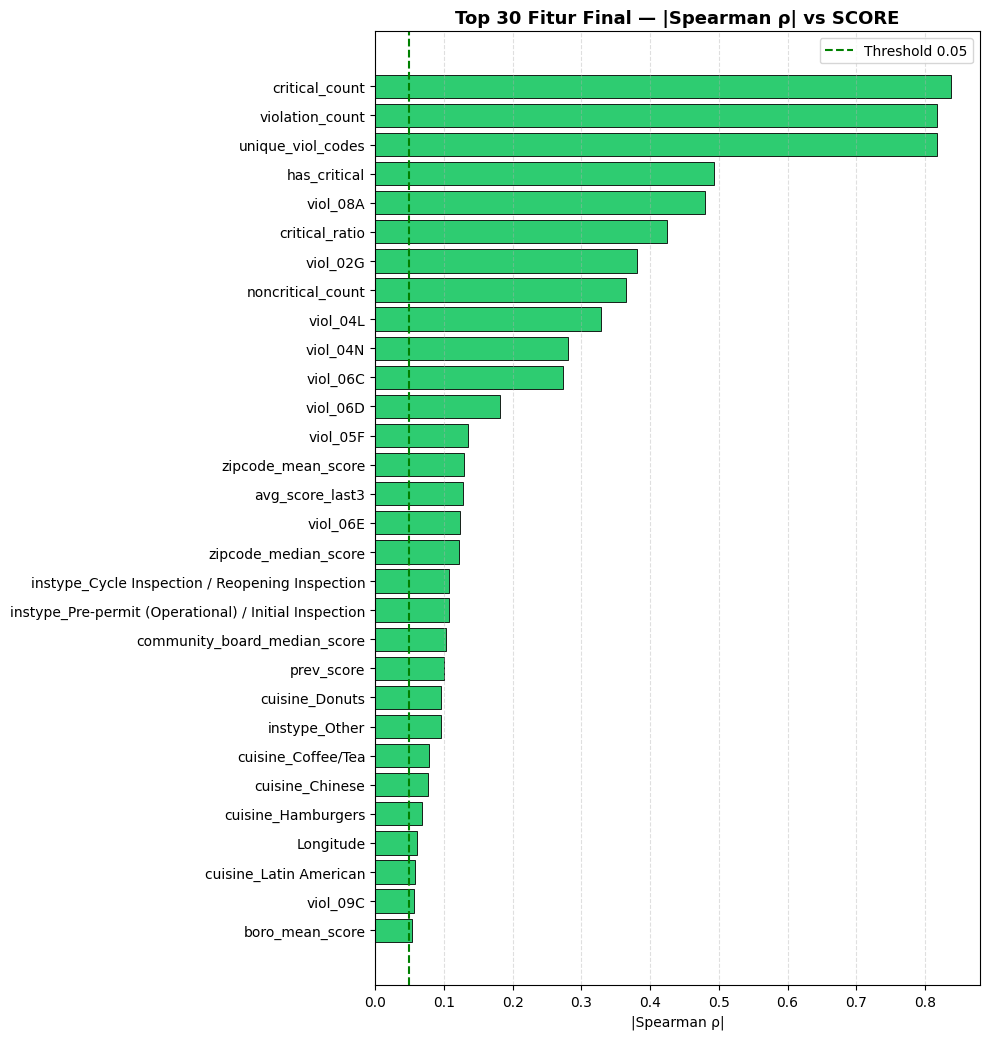


=== Top 10 fitur paling prediktif ===
          feature  abs_spearman_rho
   critical_count          0.838134
  violation_count          0.817552
unique_viol_codes          0.817552
     has_critical          0.492786
         viol_08A          0.479486
   critical_ratio          0.424459
         viol_02G          0.380793
noncritical_count          0.365133
         viol_04L          0.328939
         viol_04N          0.280551


In [42]:
final_corr = (
    df_encoded.corr(method="spearman")["SCORE"]
    .drop("SCORE")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", "SCORE": "abs_spearman_rho"})
)

print(f"Total fitur masuk modeling: {len(final_corr)}")
print(f"Fitur dengan |ρ| ≥ 0.05: {(final_corr['abs_spearman_rho'] >= 0.05).sum()}")
print(f"Fitur dengan |ρ| < 0.05: {(final_corr['abs_spearman_rho'] < 0.05).sum()}")
print()

top_n = min(30, len(final_corr))
plot_df = final_corr.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
colors = ["#2ecc71" if v >= 0.05 else "#e74c3c" for v in plot_df["abs_spearman_rho"]]
ax.barh(plot_df["feature"], plot_df["abs_spearman_rho"],
        color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(0.05, color="green", linestyle="--", linewidth=1.5, label="Threshold 0.05")
ax.set_title(f"Top {top_n} Fitur Final — |Spearman ρ| vs SCORE", fontsize=13, fontweight="bold")
ax.set_xlabel("|Spearman ρ|")
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== Top 10 fitur paling prediktif ===")
print(final_corr.head(10).to_string(index=False))

## Step 5 - Advanced Preprocessing: Handling Outlier pada SCORE ##

**Konteks dari EDA:**
- Distribusi SCORE **right-skewed** — mayoritas score berkumpul di 0–25, ada ekor panjang ke kanan
- Outlier score tinggi tetap **informatif** — bukan noise, melainkan inspeksi berisiko tinggi

**Strategi: Winsorize dulu → lalu Log1p Transform**

| Teknik | Fungsi | Urutan |
|---|---|---|
| **Winsorize (P99)** | Potong nilai ekstrem agar tidak mendominasi log scale | 1️⃣ |
| **Log1p Transform** | Perbaiki right-skewness distribusi → mendekati normal | 2️⃣ |

Mengapa log1p dan bukan log biasa? Karena SCORE bisa bernilai **0** → `log(0) = -inf`.
`log1p(x) = log(x + 1)` aman untuk nilai 0.

⚠️ **Konsekuensi:** Prediksi model akan dalam skala log → saat evaluasi dan interpretasi,
hasil prediksi harus dikembalikan ke skala asli dengan `np.expm1(y_pred)`.


=== Statistik SCORE (sebelum handling) ===
Min    : 0.0
Q1     : 9.0
Median : 13.0
Mean   : 18.12
Q3     : 24.0
P95    : 47.0
P99    : 73.0
Max    : 203.0
Skewness: 2.209

Outlier (IQR): 3,628 baris (5.3%)
Outlier ekstrem (>P99=73.0): 654 baris


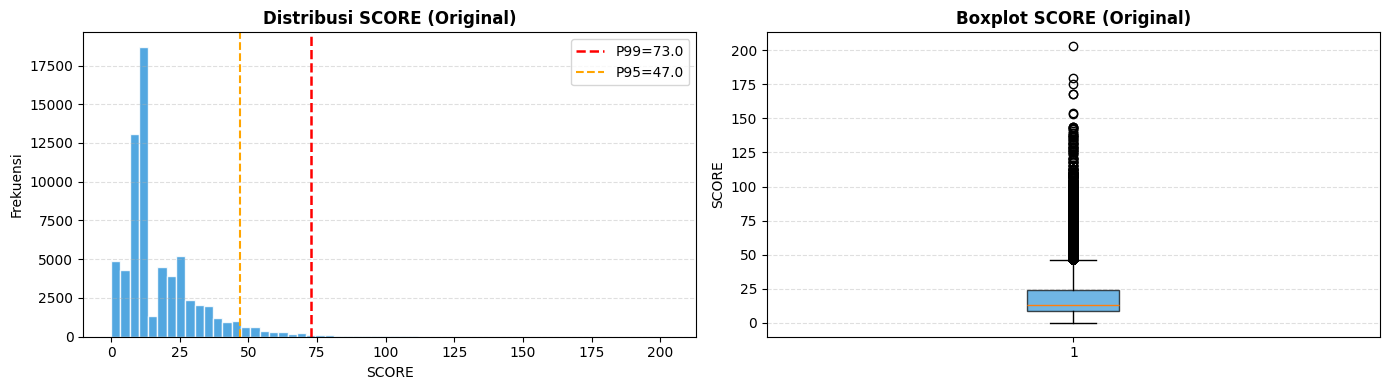

In [43]:
score = df_encoded["SCORE"]

q1  = score.quantile(0.25)
q3  = score.quantile(0.75)
iqr = q3 - q1
p99 = score.quantile(0.99)
p95 = score.quantile(0.95)

print("=== Statistik SCORE (sebelum handling) ===")
print(f"Min    : {score.min():.1f}")
print(f"Q1     : {q1:.1f}")
print(f"Median : {score.median():.1f}")
print(f"Mean   : {score.mean():.2f}")
print(f"Q3     : {q3:.1f}")
print(f"P95    : {p95:.1f}")
print(f"P99    : {p99:.1f}")
print(f"Max    : {score.max():.1f}")
print(f"Skewness: {score.skew():.3f}")
print(f"\nOutlier (IQR): {(score > q3 + 1.5*iqr).sum():,} baris ({(score > q3 + 1.5*iqr).mean()*100:.1f}%)")
print(f"Outlier ekstrem (>P99={p99:.1f}): {(score > p99).sum():,} baris")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(score, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(p99, color="red",    linestyle="--", linewidth=1.8, label=f"P99={p99:.1f}")
axes[0].axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"P95={p95:.1f}")
axes[0].set_title("Distribusi SCORE (Original)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("SCORE"); axes[0].set_ylabel("Frekuensi")
axes[0].legend(); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].boxplot(score, vert=True, patch_artist=True, boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_title("Boxplot SCORE (Original)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("SCORE"); axes[1].grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [45]:
CAP_PERCENTILE = 0.99
score_cap = df_encoded["SCORE"].quantile(CAP_PERCENTILE)
df_encoded["SCORE"] = df_encoded["SCORE"].clip(upper=score_cap)

print(f"[Winsorize] Cap di P99 = {score_cap:.1f}")
print(f"Baris yang di-cap: {(df_encoded['SCORE'] == score_cap).sum():,}")
print(f"Skewness setelah winsorize: {df_encoded['SCORE'].skew():.3f}")
print()


df_encoded["SCORE"] = np.log1p(df_encoded["SCORE"])

print(f"[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)")
print(f"Skewness setelah log1p      : {df_encoded['SCORE'].skew():.3f}")
print(f"Range SCORE sekarang        : [{df_encoded['SCORE'].min():.3f}, {df_encoded['SCORE'].max():.3f}]")
print()


[Winsorize] Cap di P99 = 4.3
Baris yang di-cap: 700
Skewness setelah winsorize: -0.714

[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)
Skewness setelah log1p      : -2.326
Range SCORE sekarang        : [0.000, 1.668]



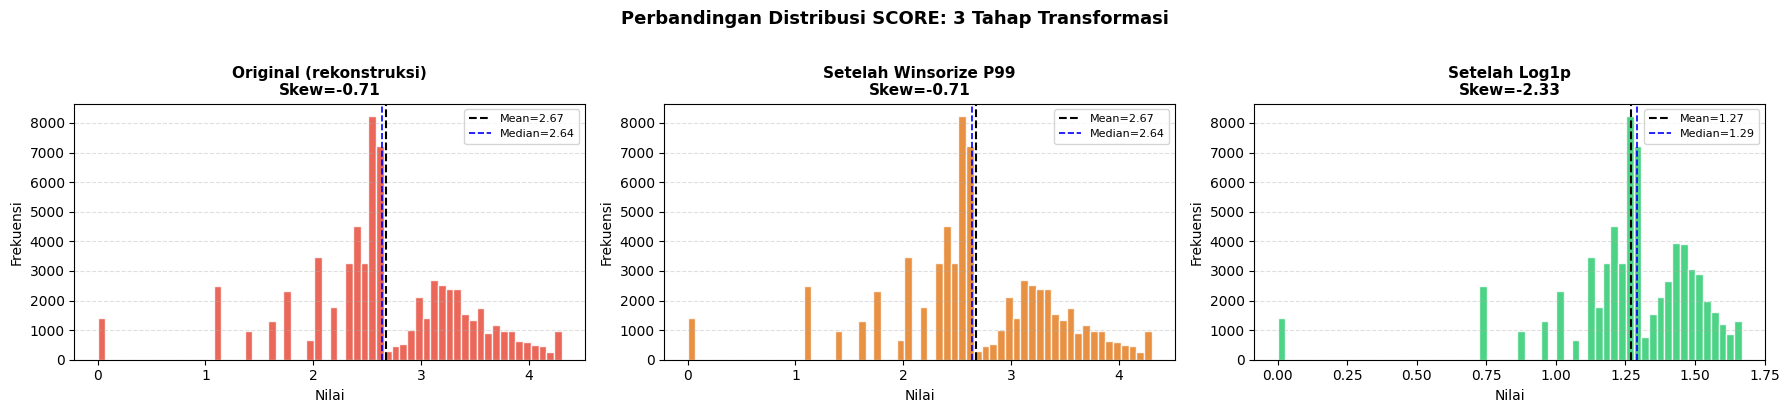

In [49]:
score_original  = df_encoded["SCORE"].apply(np.expm1).clip(upper=score_cap)  # rekonstruksi
score_winsorize = score_original 
score_log1p     = df_encoded["SCORE"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

data_stages = [
    (df_encoded["SCORE"].apply(np.expm1), "Original (rekonstruksi)", "#e74c3c"),
    (score_winsorize,                      f"Setelah Winsorize P99",   "#e67e22"),
    (score_log1p,                          "Setelah Log1p",            "#2ecc71"),
]

for ax, (data, title, color) in zip(axes, data_stages):
    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black",  linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.2f}")
    ax.axvline(data.median(), color="blue",   linestyle="--", linewidth=1.2,
               label=f"Median={data.median():.2f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Nilai"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_title(f"{title}\nSkew={data.skew():.2f}", fontsize=11, fontweight="bold")

plt.suptitle("Perbandingan Distribusi SCORE: 3 Tahap Transformasi",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 6 - Advanced Preprocessing: Feature Scaling ##

**Strategi Scaling:**

| Kolom | Scaler | Alasan |
|---|---|---|
| `SCORE` (target) | **Tidak di-scale** | Target regresi dibiarkan asli agar prediksi tetap interpretable |
| Fitur numerik kontinyu (score historis, koordinat, dll) | **RobustScaler** | Tahan terhadap outlier — menggunakan median & IQR bukan mean & std |
| Fitur count (violation_count, critical_count, dll) | **RobustScaler** | Distribusinya skewed, RobustScaler lebih aman |
| Fitur binary OHE (`cuisine_*`, `instype_*`, `viol_*`, `has_critical`) | **Tidak di-scale** | Sudah 0/1, scaling justru merusak interpretasi |

**Mengapa RobustScaler bukan StandardScaler?**
SCORE dan violation features punya outlier signifikan. StandardScaler akan terpengaruh mean & std yang terdistorsi outlier, sehingga fitur normal jadi ter-compress. RobustScaler memakai median & IQR sehingga lebih stabil.


In [51]:
from sklearn.preprocessing import RobustScaler

binary_cols = (
    [c for c in df_encoded.columns if c.startswith("cuisine_")]
    + [c for c in df_encoded.columns if c.startswith("instype_")]
    + [c for c in df_encoded.columns if c.startswith("viol_")]
    + ["has_critical"]
)
binary_cols = [c for c in binary_cols if c in df_encoded.columns]

target_col = "SCORE"

scale_cols = [
    c for c in df_encoded.select_dtypes(include="number").columns
    if c not in binary_cols and c != target_col
]

print(f"Kolom di-scale ({len(scale_cols)}):")
for c in scale_cols: print(f"  {c}")
print(f"\nKolom binary / tidak di-scale ({len(binary_cols)}): {binary_cols}")
print(f"\nTarget (tidak di-scale): {target_col}")


Kolom di-scale (12):
  Longitude
  violation_count
  unique_viol_codes
  critical_count
  noncritical_count
  critical_ratio
  prev_score
  avg_score_last3
  boro_mean_score
  zipcode_median_score
  zipcode_mean_score
  community_board_median_score

Kolom binary / tidak di-scale (32): ['cuisine_American', 'cuisine_Bakery Products/Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee/Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice, Smoothies, Fruit Salads', 'cuisine_Latin American', 'cuisine_Mexican', 'cuisine_Other', 'cuisine_Pizza', 'cuisine_Spanish', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection', 'viol_02G', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'vi

In [52]:
scaler = RobustScaler()

df_scaled = df_encoded.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

print("RobustScaler berhasil di-apply")
print(f"\nShape df_scaled: {df_scaled.shape}")
print(f"\n=== Statistik setelah scaling (sample 5 fitur) ===")
print(df_scaled[scale_cols[:5]].describe().round(3))


RobustScaler berhasil di-apply

Shape df_scaled: (68860, 45)

=== Statistik setelah scaling (sample 5 fitur) ===
       Longitude  violation_count  unique_viol_codes  critical_count  \
count  68860.000        68860.000          68860.000       68860.000   
mean       0.179            0.123              0.123           0.408   
std        0.866            1.056              1.056           0.763   
min       -3.344           -1.500             -1.500          -0.500   
25%       -0.356           -0.500             -0.500           0.000   
50%        0.000            0.000              0.000           0.000   
75%        0.644            0.500              0.500           1.000   
max        2.957            8.000              8.000           6.000   

       noncritical_count  
count          68860.000  
mean               0.431  
std                1.067  
min               -1.000  
25%                0.000  
50%                0.000  
75%                1.000  
max                7.0

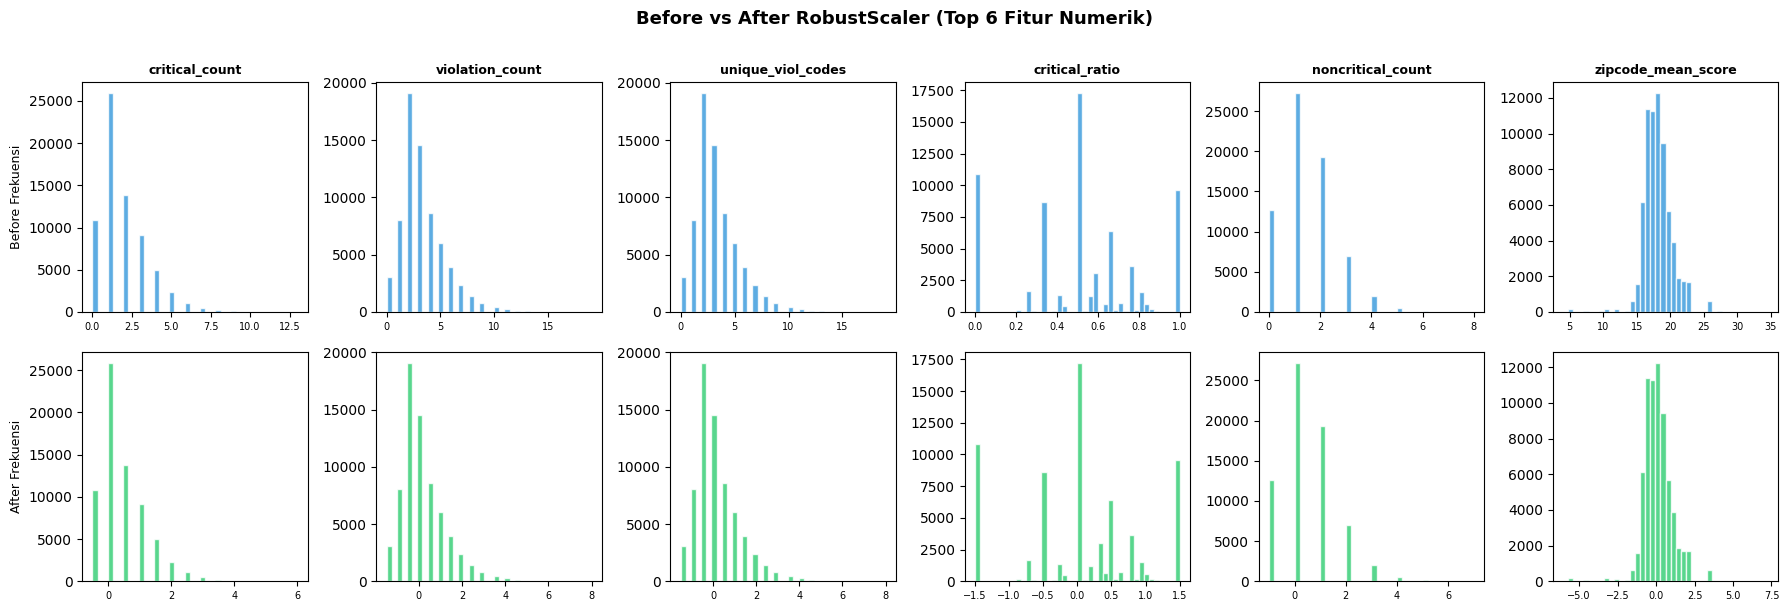

In [53]:
top6_scale = [c for c in final_corr["feature"].tolist() if c in scale_cols][:6]

fig, axes = plt.subplots(2, len(top6_scale), figsize=(18, 6))

for i, col in enumerate(top6_scale):
    axes[0, i].hist(df_encoded[col].dropna(), bins=40,
                    color="#3498db", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(col, fontsize=9, fontweight="bold")
    axes[0, i].set_ylabel("Frekuensi" if i == 0 else "")
    axes[0, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[0, i].set_ylabel("Before Frekuensi", fontsize=9)

    axes[1, i].hist(df_scaled[col].dropna(), bins=40,
                    color="#2ecc71", edgecolor="white", alpha=0.8)
    axes[1, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[1, i].set_ylabel("After Frekuensi", fontsize=9)

plt.suptitle("Before vs After RobustScaler (Top 6 Fitur Numerik)", 
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Step 8 - Advanced Preprocessing: Train-Test Split (Temporal) ##

**Mengapa 3-Way Temporal Split (Train / Validation / Test)?**

| Set | Proporsi | Fungsi |
|---|---|---|
| **Train** | 70% | Melatih model |
| **Validation** | 15% | Tuning hyperparameter, pilih model terbaik |
| **Test** | 15% | Evaluasi final — **hanya disentuh sekali di akhir** |

Kalau hanya pakai train/test dan tuning dilakukan berdasarkan test set → test set "bocor" ke proses
training secara tidak langsung → hasil evaluasi **overly optimistic**, tidak mencerminkan performa di data baru.

Split tetap **temporal** dan berurutan karena data ini time-series inspeksi:
```
[────── Train (70%) ──────────][── Val (15%) ──][── Test (15%) ──]
 terlama                                                  terbaru
```

⚠️  **Target encoding di-refit dari train saja**, lalu di-apply ke val dan test.


In [54]:
df_split = df_scaled.copy()
df_split["INSPECTION DATE"] = pd.to_datetime(df_ids["INSPECTION DATE"].values)
df_split["CAMIS"]           = df_ids["CAMIS"].values
df_split = df_split.sort_values("INSPECTION DATE").reset_index(drop=True)

n = len(df_split)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_split.iloc[:train_end].copy()
val_df   = df_split.iloc[train_end:val_end].copy()
test_df  = df_split.iloc[val_end:].copy()

print(f"Total data       : {n:,}")
print(f"\nTrain  : {len(train_df):,} baris ({len(train_df)/n*100:.1f}%)")
print(f"  Periode: {train_df['INSPECTION DATE'].min().date()} → {train_df['INSPECTION DATE'].max().date()}")
print(f"\nVal    : {len(val_df):,} baris ({len(val_df)/n*100:.1f}%)")
print(f"  Periode: {val_df['INSPECTION DATE'].min().date()} → {val_df['INSPECTION DATE'].max().date()}")
print(f"\nTest   : {len(test_df):,} baris ({len(test_df)/n*100:.1f}%)")
print(f"  Periode: {test_df['INSPECTION DATE'].min().date()} → {test_df['INSPECTION DATE'].max().date()}")

Total data       : 68,860

Train  : 48,202 baris (70.0%)
  Periode: 2023-03-03 → 2025-05-09

Val    : 10,329 baris (15.0%)
  Periode: 2025-05-09 → 2025-10-07

Test   : 10,329 baris (15.0%)
  Periode: 2025-10-07 → 2026-02-28


In [ ]:
te_map = {
    "zipcode_mean_score":            ("ZIPCODE",         "mean"),
    "zipcode_median_score":          ("ZIPCODE",         "median"),
    "boro_mean_score":               ("BORO",            "mean"),
    "community_board_median_score":  ("Community_Board", "median"),
}

camis_geo = (
    df_ins[["CAMIS", "ZIPCODE", "BORO", "Community_Board"]]
    .copy()
    .astype(str)
    .replace("nan", pd.NA)        
    .dropna(subset=["CAMIS"])     
    .groupby("CAMIS", as_index=False)
    .first()                    
)

for df_ in [train_df, val_df, test_df]:
    df_["CAMIS"] = df_["CAMIS"].astype(str)

for geo_col in ["ZIPCODE", "BORO", "Community_Board"]:
    camis_to_geo = camis_geo.set_index("CAMIS")[geo_col]
    for df_ in [train_df, val_df, test_df]:
        df_[geo_col] = df_["CAMIS"].map(camis_to_geo)

global_median_train = train_df["SCORE"].median()

for new_col, (geo_col, agg_fn) in te_map.items():
    if new_col not in train_df.columns:
        continue
    stats_dict = (
        train_df.dropna(subset=[geo_col])
        .groupby(geo_col)["SCORE"]
        .agg(agg_fn)
        .to_dict()
    )
    for df_ in [train_df, val_df, test_df]:
        df_[new_col] = df_[geo_col].map(stats_dict).fillna(global_median_train)

geo_temp_cols = ["ZIPCODE", "BORO", "Community_Board"]
for df_ in [train_df, val_df, test_df]:
    df_.drop(columns=geo_temp_cols, errors="ignore", inplace=True)

print("\u2705 Target encoding di-refit dari train set saja, applied ke val & test")
print(f"\nTrain: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")


✅ Target encoding di-refit dari train set saja, applied ke val & test

Train: (48202, 47) | Val: (10329, 47) | Test: (10329, 47)


In [ ]:
drop_final = ["INSPECTION DATE", "CAMIS"]

X_train = train_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_train = train_df["SCORE"]

X_val   = val_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_val   = val_df["SCORE"]

X_test  = test_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_test  = test_df["SCORE"]

print("=" * 55)
print("  HASIL AKHIR PREPROCESSING")
print("=" * 55)
print(f"X_train : {X_train.shape}  | y mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"X_val   : {X_val.shape}   | y mean={y_val.mean():.3f}, std={y_val.std():.3f}")
print(f"X_test  : {X_test.shape}   | y mean={y_test.mean():.3f}, std={y_test.std():.3f}")
print(f"\nJumlah fitur masuk modeling: {X_train.shape[1]}")
print(f"\ny dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli")
print(f"\nFeature list:")
print(X_train.columns.tolist())


  HASIL AKHIR PREPROCESSING
X_train : (48202, 44)  | y mean=1.271, std=0.258
X_val   : (10329, 44)   | y mean=1.260, std=0.323
X_test  : (10329, 44)   | y mean=1.283, std=0.249

Jumlah fitur masuk modeling: 44

y dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli

Data siap untuk modeling!

Feature list:
['Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02G', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score', 'cuisine_American', 'cuisine_Bakery Products/Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee/Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice, Smoothies, Fruit Salads', 'cuisine_Latin American', 'cuisine_Mexican', 'cuisi

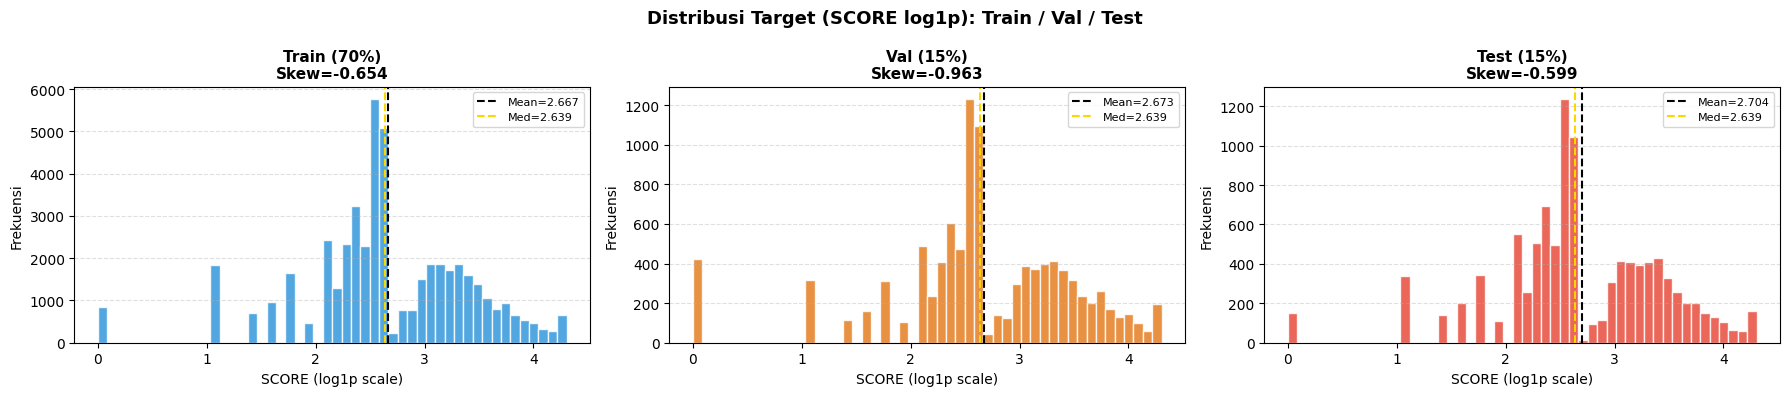

Cek: distribusi ketiga set harus mirip
Train skewness : -0.654
Val   skewness : -0.963
Test  skewness : -0.599


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sets = [
    (y_train, "Train (70%)",  "#3498db"),
    (y_val,   "Val (15%)",    "#e67e22"),
    (y_test,  "Test (15%)",   "#e74c3c"),
]

for ax, (data, label, color) in zip(axes, sets):
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black", linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.3f}")
    ax.axvline(data.median(), color="gold",  linestyle="--", linewidth=1.5,
               label=f"Med={data.median():.3f}")
    ax.set_title(f"{label}\nSkew={data.skew():.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("SCORE (log1p scale)"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribusi Target (SCORE log1p): Train / Val / Test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Cek: distribusi ketiga set harus mirip")
print(f"Train skewness : {y_train.skew():.3f}")
print(f"Val   skewness : {y_val.skew():.3f}")
print(f"Test  skewness : {y_test.skew():.3f}")


# Modeling ##

**Roadmap Modeling:**

| Tahap | Model | Tujuan |
|---|---|---|
| **1** | Ridge, Lasso, ElasticNet | Atasi overfitting Linear Regression, feature selection implisit |
| **2** | Random Forest, XGBoost, LightGBM | Model non-linear yang lebih powerful untuk data tabular |
| **3** | Perbandingan semua model | Pilih model terbaik berdasarkan Val R² dan gap overfitting |

**Metrik Evaluasi:**
- **RMSE** (log1p scale) — sensitif terhadap error besar
- **MAE** (log1p scale) — lebih robust terhadap outlier
- **R²** — proporsi variansi yang dijelaskan model
- **Gap Train-Val R²** — indikator overfitting (target ≤ 0.05)

⚠️ Semua tuning dilakukan terhadap **Val set**. **Test set hanya digunakan di akhir.**


In [56]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

def evaluate(model, X_tr, y_tr, X_vl, y_vl, name):
    """Evaluasi model di train dan val, return dict hasil."""
    y_tr_pred = model.predict(X_tr)
    y_vl_pred = model.predict(X_vl)

    res = {
        "Model":        name,
        "Train RMSE":   np.sqrt(mean_squared_error(y_tr, y_tr_pred)),
        "Val RMSE":     np.sqrt(mean_squared_error(y_vl, y_vl_pred)),
        "Train MAE":    mean_absolute_error(y_tr, y_tr_pred),
        "Val MAE":      mean_absolute_error(y_vl, y_vl_pred),
        "Train R²":     r2_score(y_tr, y_tr_pred),
        "Val R²":       r2_score(y_vl, y_vl_pred),
    }
    res["Gap R²"] = res["Train R²"] - res["Val R²"]

    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Train RMSE: {res['Train RMSE']:.4f}  |  Val RMSE: {res['Val RMSE']:.4f}")
    print(f"  Train MAE : {res['Train MAE']:.4f}  |  Val MAE : {res['Val MAE']:.4f}")
    print(f"  Train R²  : {res['Train R²']:.4f}  |  Val R²  : {res['Val R²']:.4f}")
    print(f"  Gap R²    : {res['Gap R²']:.4f}  {'✅' if res['Gap R²'] <= 0.05 else '⚠️  overfitting'}")
    return res

all_results = [] 
print("Helper dan library siap")


Helper dan library siap


## Tahap 1 — Regularized Linear Models (Ridge / Lasso / ElasticNet) ##

**Strategi tuning alpha:**
- `alpha` mengontrol kekuatan regularisasi — semakin besar, semakin model di-constrain
- Dicoba rentang dari sangat kecil (0.01) sampai besar (1000) dalam skala logaritmik
- Pilih `alpha` yang memberikan **Val R² tertinggi** dengan **gap terkecil**

| Model | Penalti | Efek |
|---|---|---|
| **Ridge** | L2 (kuadrat koefisien) | Shrink semua koefisien, tidak ada yang jadi 0 |
| **Lasso** | L1 (nilai absolut) | Beberapa koefisien jadi 0 → implicit feature selection |
| **ElasticNet** | L1 + L2 | Kombinasi keduanya, lebih stabil dari Lasso jika ada fitur berkorelasi |


In [58]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

alphas = np.logspace(-2, 4, 50) 

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring="r2")
ridge_cv.fit(X_train, y_train)

print(f"Ridge — Best alpha: {ridge_cv.alpha_:.4f}")

ridge_best = Ridge(alpha=ridge_cv.alpha_)
ridge_best.fit(X_train, y_train)
res_ridge = evaluate(ridge_best, X_train, y_train, X_val, y_val, "Ridge")
all_results.append(res_ridge)

Ridge — Best alpha: 62.5055
  Ridge
  Train RMSE: 0.1589  |  Val RMSE: 0.2226
  Train MAE : 0.0834  |  Val MAE : 0.1081
  Train R²  : 0.6204  |  Val R²  : 0.5244
  Gap R²    : 0.0960  ⚠️  overfitting


In [59]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)

print(f"Lasso — Best alpha: {lasso_cv.alpha_:.6f}")

n_zero = (np.abs(lasso_cv.coef_) < 1e-6).sum()
print(f"Fitur di-eliminasi Lasso: {n_zero} / {X_train.shape[1]}")
print(f"Fitur aktif             : {X_train.shape[1] - n_zero}")

lasso_best = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_best.fit(X_train, y_train)
res_lasso = evaluate(lasso_best, X_train, y_train, X_val, y_val, "Lasso")
all_results.append(res_lasso)

Lasso — Best alpha: 0.010000
Fitur di-eliminasi Lasso: 38 / 44
Fitur aktif             : 6
  Lasso
  Train RMSE: 0.1681  |  Val RMSE: 0.2220
  Train MAE : 0.0884  |  Val MAE : 0.1111
  Train R²  : 0.5752  |  Val R²  : 0.5271
  Gap R²    : 0.0482  ✅


In [60]:
enet_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95],  
    cv=5,
    max_iter=10000,
    random_state=42
)
enet_cv.fit(X_train, y_train)

print(f"ElasticNet — Best alpha  : {enet_cv.alpha_:.6f}")
print(f"ElasticNet — Best l1_ratio: {enet_cv.l1_ratio_:.2f}")

enet_best = ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10000)
enet_best.fit(X_train, y_train)
res_enet = evaluate(enet_best, X_train, y_train, X_val, y_val, "ElasticNet")
all_results.append(res_enet)


ElasticNet — Best alpha  : 0.010000
ElasticNet — Best l1_ratio: 0.10
  ElasticNet
  Train RMSE: 0.1608  |  Val RMSE: 0.2208
  Train MAE : 0.0835  |  Val MAE : 0.1077
  Train R²  : 0.6111  |  Val R²  : 0.5322
  Gap R²    : 0.0789  ⚠️  overfitting


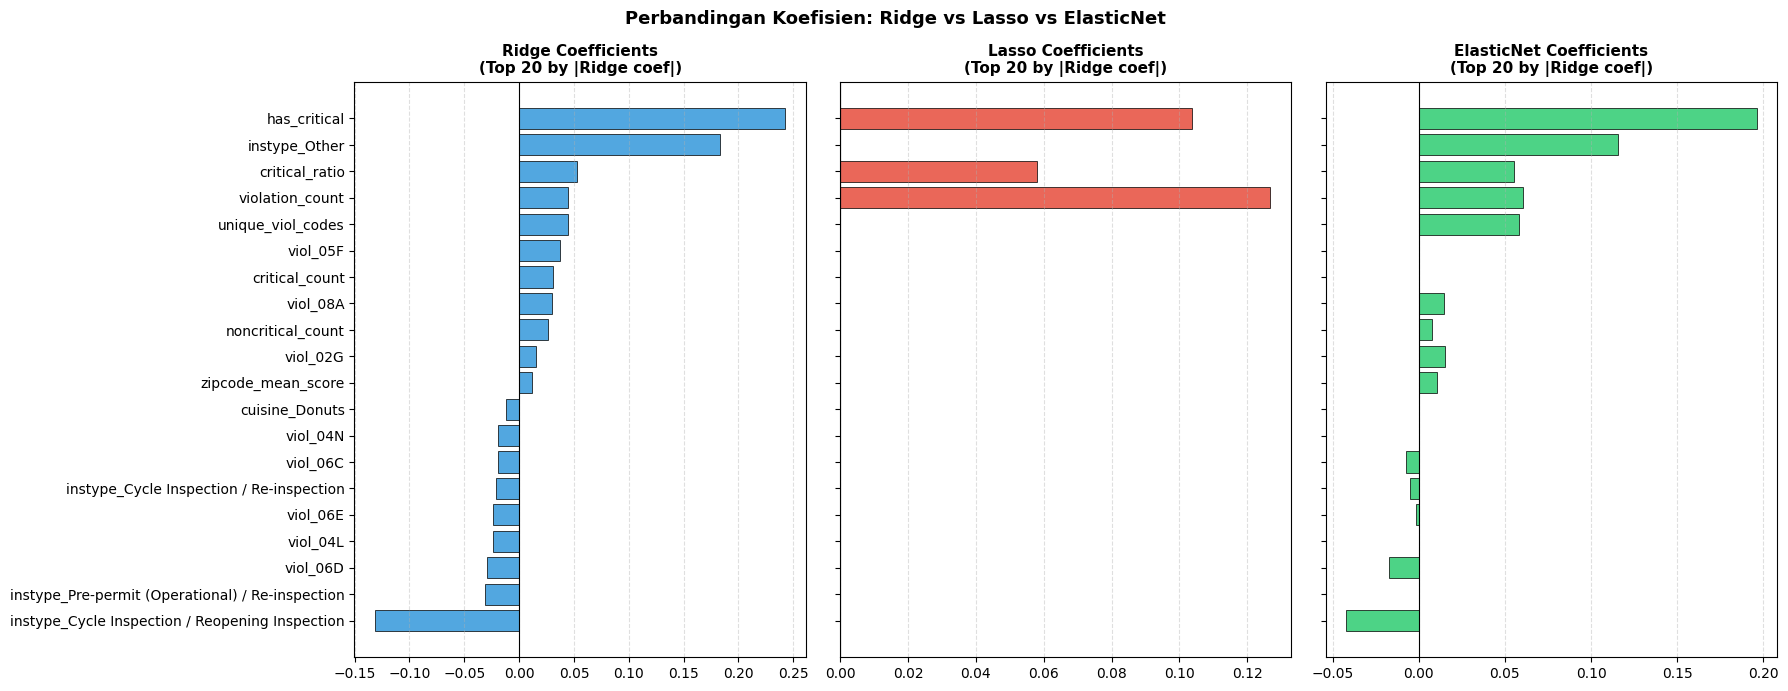

In [61]:
feat_names = X_train.columns.tolist()

coef_df = pd.DataFrame({
    "feature": feat_names,
    "Ridge":   ridge_best.coef_,
    "Lasso":   lasso_best.coef_,
    "ElasticNet": enet_best.coef_,
})

top20 = coef_df.reindex(coef_df["Ridge"].abs().nlargest(20).index)
top20 = top20.sort_values("Ridge")

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
for ax, col, color in zip(axes, ["Ridge", "Lasso", "ElasticNet"],
                           ["#3498db", "#e74c3c", "#2ecc71"]):
    bars = ax.barh(top20["feature"], top20[col], color=color,
                   edgecolor="black", linewidth=0.6, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{col} Coefficients\n(Top 20 by |Ridge coef|)",
                 fontsize=11, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Perbandingan Koefisien: Ridge vs Lasso vs ElasticNet",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Tahap 2 — Tree-Based Models (Random Forest / XGBoost / LightGBM) ##

**Mengapa tree-based lebih cocok untuk data tabular ini?**
- Tidak asumsi linearitas — hubungan `critical_count` vs `SCORE` mungkin non-linear
- Otomatis menangani interaksi antar fitur (contoh: `critical_count` tinggi + `INSPECTION TYPE` tertentu)
- Lebih robust terhadap outlier dan skewness residual
- Tidak butuh scaling — fitur binary OHE dan numerik bisa masuk langsung

**Catatan:** Karena SCORE sudah di-log1p, tree model tetap dilatih di skala log1p. Konsisten dengan linear model.


In [62]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    max_features=0.6,      
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
res_rf = evaluate(rf, X_train, y_train, X_val, y_val, "Random Forest")
all_results.append(res_rf)


  Random Forest
  Train RMSE: 0.1076  |  Val RMSE: 0.1455
  Train MAE : 0.0507  |  Val MAE : 0.0640
  Train R²  : 0.8259  |  Val R²  : 0.7969
  Gap R²    : 0.0290  ✅


In [63]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,          
    reg_lambda=1.0,         
    early_stopping_rounds=30,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print(f"XGBoost — Best iteration: {xgb_model.best_iteration}")
res_xgb = evaluate(xgb_model, X_train, y_train, X_val, y_val, "XGBoost")
all_results.append(res_xgb)


XGBoost — Best iteration: 186
  XGBoost
  Train RMSE: 0.1130  |  Val RMSE: 0.1452
  Train MAE : 0.0546  |  Val MAE : 0.0634
  Train R²  : 0.8079  |  Val R²  : 0.7978
  Gap R²    : 0.0102  ✅


In [64]:
import re

def clean_col_name(col):
    return re.sub(r'[^A-Za-z0-9_]', '_', col)

X_train.columns = [clean_col_name(c) for c in X_train.columns]
X_val.columns   = [clean_col_name(c) for c in X_val.columns]
X_test.columns  = [clean_col_name(c) for c in X_test.columns]

print("✅ Nama kolom dibersihkan")
print(X_train.columns.tolist())

✅ Nama kolom dibersihkan
['Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02G', 'viol_04L', 'viol_04N', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06E', 'viol_08A', 'viol_09C', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score', 'cuisine_American', 'cuisine_Bakery_Products_Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee_Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice__Smoothies__Fruit_Salads', 'cuisine_Latin_American', 'cuisine_Mexican', 'cuisine_Other', 'cuisine_Pizza', 'cuisine_Spanish', 'instype_Cycle_Inspection___Initial_Inspection', 'instype_Cycle_Inspection___Re_inspection', 'instype_Cycle_Inspection___Reopening_Inspection', 'instype_Other', 'instype_Pre_permit__Operational____Initial_Inspection', 'instype_Pre_permit__Operational____

In [65]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)]
)
print(f"LightGBM — Best iteration: {lgb_model.best_iteration_}")
res_lgb = evaluate(lgb_model, X_train, y_train, X_val, y_val, "LightGBM")
all_results.append(res_lgb)


LightGBM — Best iteration: 227
  LightGBM
  Train RMSE: 0.1158  |  Val RMSE: 0.1463
  Train MAE : 0.0550  |  Val MAE : 0.0640
  Train R²  : 0.7983  |  Val R²  : 0.7947
  Gap R²    : 0.0036  ✅


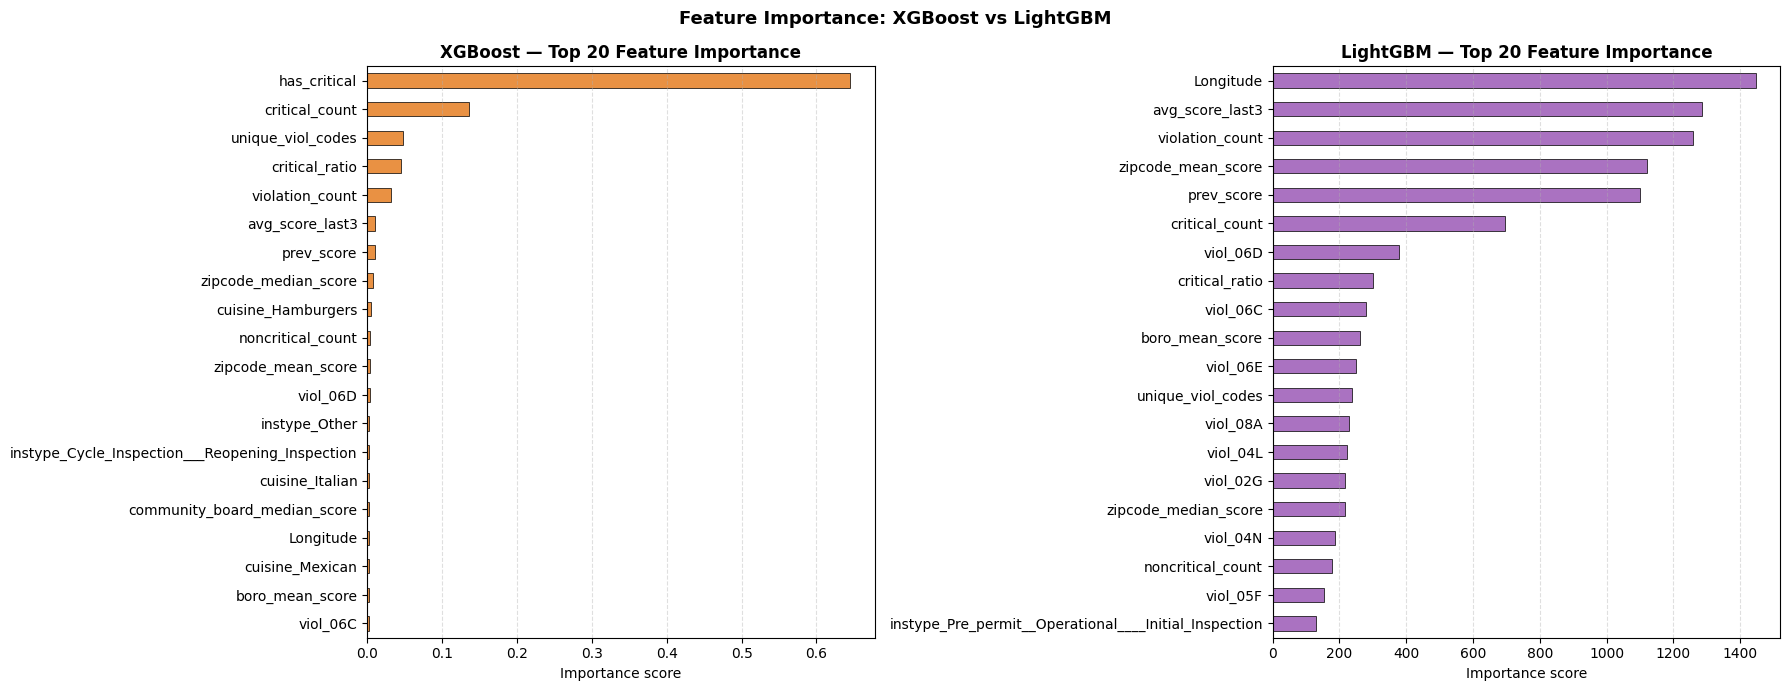

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model, name, color in zip(
    axes,
    [xgb_model, lgb_model],
    ["XGBoost", "LightGBM"],
    ["#e67e22", "#9b59b6"]
):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top20_imp = importances.nlargest(20).sort_values()

    top20_imp.plot(kind="barh", ax=ax, color=color, edgecolor="black",
                   linewidth=0.6, alpha=0.85)
    ax.set_title(f"{name} — Top 20 Feature Importance",
                 fontsize=12, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.set_xlabel("Importance score")

plt.suptitle("Feature Importance: XGBoost vs LightGBM",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Tahap 3 — Perbandingan Semua Model & Evaluasi Final di Test Set ##

In [ ]:
df_results = pd.DataFrame(all_results).set_index("Model")
df_results = df_results.round(4).sort_values("Val R²", ascending=False)

print("=" * 70)
print("  PERBANDINGAN SEMUA MODEL (diurutkan Val R²)")
print("=" * 70)
print(df_results[["Train R²", "Val R²", "Gap R²", "Val RMSE", "Val MAE"]].to_string())

best_model_name = df_results["Val R²"].idxmax()
print(f"\n🏆 Model terbaik di Val set: {best_model_name}")
print(f"   Val R²   : {df_results.loc[best_model_name, 'Val R²']:.4f}")
print(f"   Val RMSE : {df_results.loc[best_model_name, 'Val RMSE']:.4f}")
print(f"   Gap R²   : {df_results.loc[best_model_name, 'Gap R²']:.4f}")


  PERBANDINGAN SEMUA MODEL (diurutkan Val R²)
               Train R²  Val R²  Gap R²  Val RMSE  Val MAE
Model                                                     
XGBoost          0.8079  0.7978  0.0102    0.1452   0.0634
Random Forest    0.8259  0.7969  0.0290    0.1455   0.0640
LightGBM         0.7983  0.7947  0.0036    0.1463   0.0640
ElasticNet       0.6111  0.5322  0.0789    0.2208   0.1077
Lasso            0.5752  0.5271  0.0482    0.2220   0.1111
Ridge            0.6204  0.5244  0.0960    0.2226   0.1081
Ridge            0.6204  0.5244  0.0960    0.2226   0.1081

🏆 Model terbaik di Val set: XGBoost
   Val R²   : 0.7978
   Val RMSE : 0.1452
   Gap R²   : 0.0102


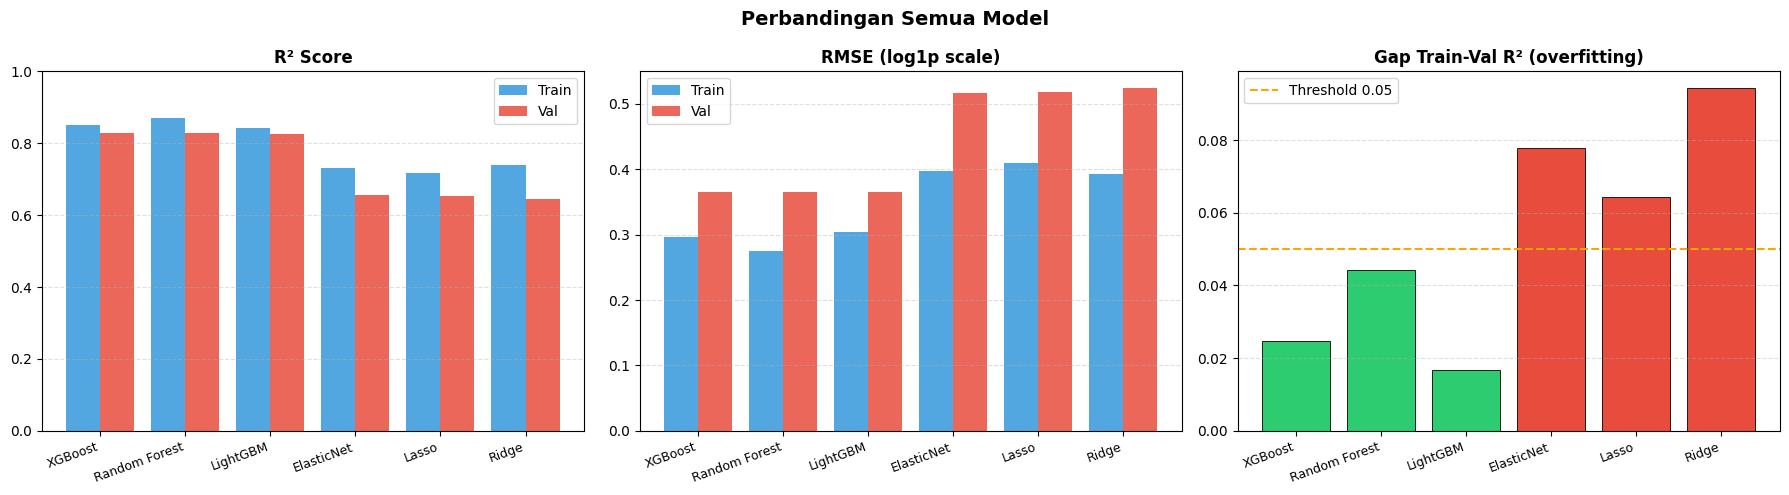

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models   = df_results.index.tolist()
x        = np.arange(len(models))
colors_t = "#3498db"
colors_v = "#e74c3c"

axes[0].bar(x - 0.2, df_results["Train R²"], 0.4, label="Train", color=colors_t, alpha=0.85)
axes[0].bar(x + 0.2, df_results["Val R²"],   0.4, label="Val",   color=colors_v, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=20, ha="right", fontsize=9)
axes[0].set_title("R² Score", fontweight="bold"); axes[0].legend()
axes[0].set_ylim(0, 1); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].bar(x - 0.2, df_results["Train RMSE"], 0.4, label="Train", color=colors_t, alpha=0.85)
axes[1].bar(x + 0.2, df_results["Val RMSE"],   0.4, label="Val",   color=colors_v, alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=20, ha="right", fontsize=9)
axes[1].set_title("RMSE (log1p scale)", fontweight="bold"); axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

gap_colors = ["#2ecc71" if g <= 0.05 else "#e74c3c" for g in df_results["Gap R²"]]
axes[2].bar(x, df_results["Gap R²"], color=gap_colors, edgecolor="black", linewidth=0.6)
axes[2].axhline(0.05, color="orange", linestyle="--", linewidth=1.5, label="Threshold 0.05")
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=20, ha="right", fontsize=9)
axes[2].set_title("Gap Train-Val R² (overfitting)", fontweight="bold"); axes[2].legend()
axes[2].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Perbandingan Semua Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
model_map = {
    "Ridge":        ridge_best,
    "Lasso":        lasso_best,
    "ElasticNet":   enet_best,
    "Random Forest": rf,
    "XGBoost":      xgb_model,
    "LightGBM":     lgb_model,
}

best_model = model_map[best_model_name]
X_test_fixed = X_test.copy()
X_test_fixed.columns = best_model.feature_names_in_

y_test_pred = best_model.predict(X_test_fixed)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)

y_test_orig      = np.expm1(y_test)
y_test_pred_orig = np.expm1(y_test_pred)
test_rmse_orig   = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
test_mae_orig    = mean_absolute_error(y_test_orig, y_test_pred_orig)

print("=" * 55)
print(f"  EVALUASI FINAL: {best_model_name}")
print("=" * 55)
print(f"  Test R²        : {test_r2:.4f}")
print(f"  Test RMSE      : {test_rmse:.4f}  (log1p scale)")
print(f"  Test MAE       : {test_mae:.4f}  (log1p scale)")
print(f"  Test RMSE      : {test_rmse_orig:.2f}   (skala SCORE asli)")
print(f"  Test MAE       : {test_mae_orig:.2f}   (skala SCORE asli)")

  EVALUASI FINAL: XGBoost
  Test R²        : 0.8274
  Test RMSE      : 0.3158  (log1p scale)
  Test MAE       : 0.1758  (log1p scale)
  Test RMSE      : 6.61   (skala SCORE asli)
  Test MAE       : 3.15   (skala SCORE asli)


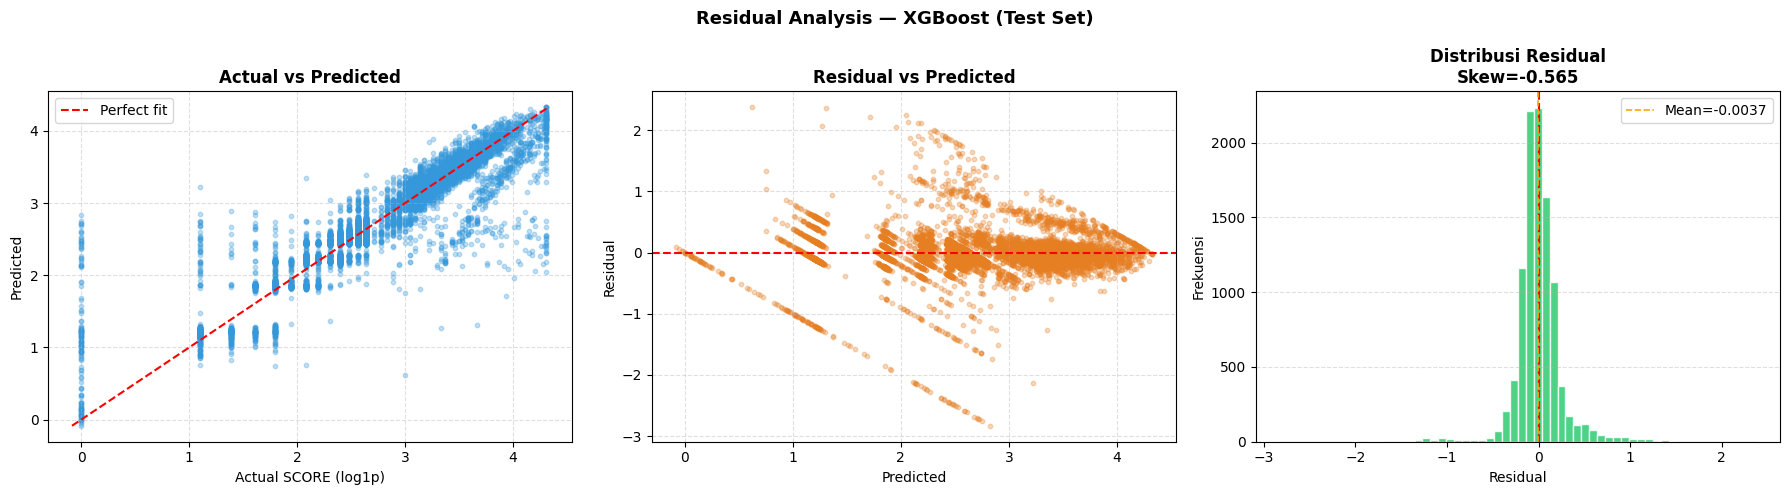

In [ ]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=10, color="#3498db")
mn = min(y_test.min(), y_test_pred.min())
mx = max(y_test.max(), y_test_pred.max())
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual SCORE (log1p)"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted", fontweight="bold"); axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.4)

axes[1].scatter(y_test_pred, residuals, alpha=0.3, s=10, color="#e67e22")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual vs Predicted", fontweight="bold")
axes[1].grid(linestyle="--", alpha=0.4)

axes[2].hist(residuals, bins=60, color="#2ecc71", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].axvline(residuals.mean(), color="orange", linestyle="--", linewidth=1.2,
                label=f"Mean={residuals.mean():.4f}")
axes[2].set_xlabel("Residual"); axes[2].set_ylabel("Frekuensi")
axes[2].set_title(f"Distribusi Residual\nSkew={residuals.skew():.3f}", fontweight="bold")
axes[2].legend(); axes[2].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle(f"Residual Analysis — {best_model_name} (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Computing learning curve: Random Forest...
Computing learning curve: XGBoost...
Computing learning curve: LightGBM...


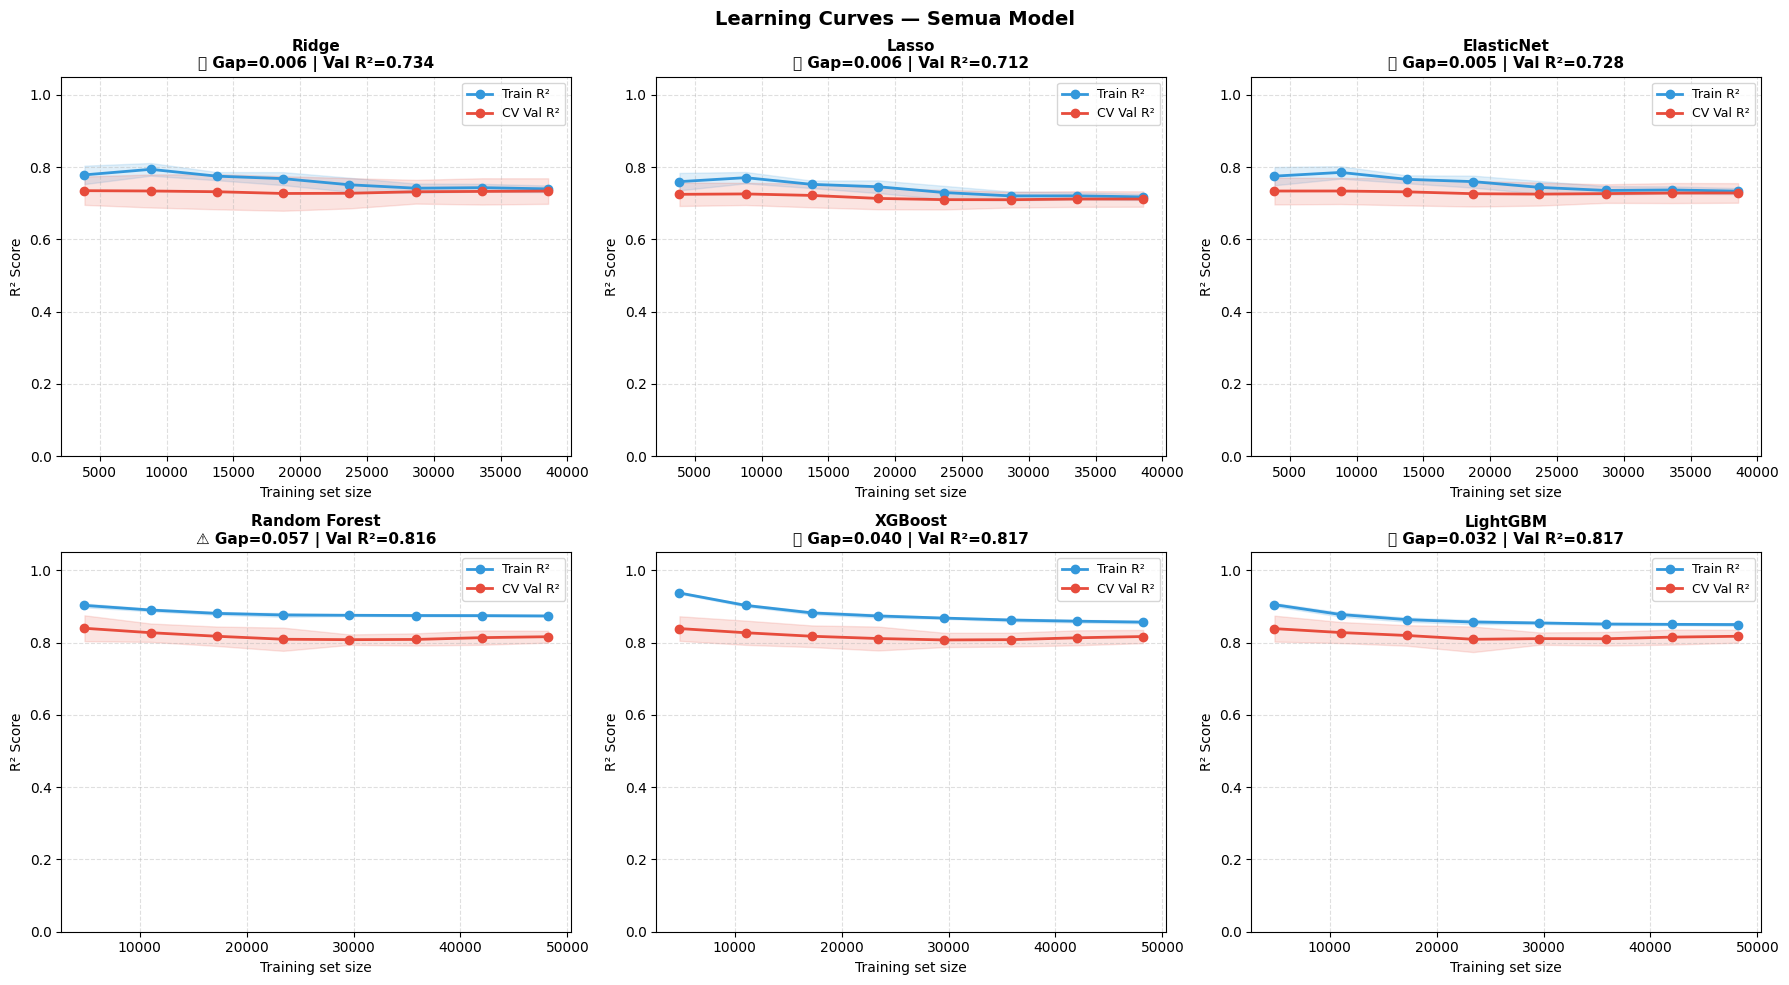

In [ ]:
from sklearn.model_selection import learning_curve, KFold

train_sizes_abs = np.linspace(0.1, 1.0, 8)

def manual_learning_curve(model_class, model_params, X, y, train_sizes):
    """Learning curve manual untuk model dengan early stopping."""
    kf = KFold(n_splits=5, shuffle=False)
    results = []

    for frac in train_sizes:
        n = int(len(X) * frac)
        X_sub = X.iloc[:n]
        y_sub = y.iloc[:n]

        tr_scores, vl_scores = [], []
        for tr_idx, vl_idx in kf.split(X_sub):
            X_tr, X_vl = X_sub.iloc[tr_idx], X_sub.iloc[vl_idx]
            y_tr, y_vl = y_sub.iloc[tr_idx], y_sub.iloc[vl_idx]

            m = model_class(**model_params)
            m.fit(X_tr, y_tr)  

            tr_scores.append(r2_score(y_tr, m.predict(X_tr)))
            vl_scores.append(r2_score(y_vl, m.predict(X_vl)))

        results.append((n, np.mean(tr_scores), np.std(tr_scores),
                           np.mean(vl_scores), np.std(vl_scores)))

    return zip(*results)  
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def plot_lc(ax, sizes, tr_mean, tr_std, vl_mean, vl_std, name):
    tr_mean, tr_std = np.array(tr_mean), np.array(tr_std)
    vl_mean, vl_std = np.array(vl_mean), np.array(vl_std)

    ax.plot(sizes, tr_mean, "o-", color="#3498db", linewidth=2, label="Train R²")
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#3498db")
    ax.plot(sizes, vl_mean, "o-", color="#e74c3c", linewidth=2, label="CV Val R²")
    ax.fill_between(sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.15, color="#e74c3c")

    gap    = tr_mean[-1] - vl_mean[-1]
    status = "✅" if gap <= 0.05 else "⚠️"
    ax.set_title(f"{name}\n{status} Gap={gap:.3f} | Val R²={vl_mean[-1]:.3f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Training set size"); ax.set_ylabel("R² Score")
    ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.4); ax.set_ylim(0, 1.05)

for ax, (name, model) in zip(axes.flatten()[:3],
    [("Ridge", ridge_best), ("Lasso", lasso_best), ("ElasticNet", enet_best)]):
    sz, tr_s, vl_s = learning_curve(model, X_train, y_train,
                                     train_sizes=train_sizes_abs, cv=5,
                                     scoring="r2", n_jobs=-1, shuffle=False)
    plot_lc(ax, sz, tr_s.mean(1), tr_s.std(1), vl_s.mean(1), vl_s.std(1), name)

tree_configs = [
    ("Random Forest", RandomForestRegressor,
     dict(n_estimators=100, max_depth=15, min_samples_leaf=5,
          max_features=0.6, n_jobs=-1, random_state=42)),
    ("XGBoost", xgb.XGBRegressor,
     dict(n_estimators=200, learning_rate=0.05, max_depth=6,
          subsample=0.8, colsample_bytree=0.8, random_state=42,
          n_jobs=-1, verbosity=0)),
    ("LightGBM", lgb.LGBMRegressor,
     dict(n_estimators=200, learning_rate=0.05, num_leaves=63,
          max_depth=7, subsample=0.8, colsample_bytree=0.8,
          random_state=42, n_jobs=-1, verbose=-1)),
]

for ax, (name, cls, params) in zip(axes.flatten()[3:], tree_configs):
    print(f"Computing learning curve: {name}...")
    sz, tr_m, tr_s, vl_m, vl_s = manual_learning_curve(cls, params, X_train, y_train, train_sizes_abs)
    plot_lc(ax, list(sz), list(tr_m), list(tr_s), list(vl_m), list(vl_s), name)

plt.suptitle("Learning Curves — Semua Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()